# ERM untied exp

In [93]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# run_id = "20251103_145346" # rho = 1 
run_id = "20251103_1841" # rho = 0.75

## 1. experiment config

In [94]:
# --- Path to your local folder ---
config_path = f"../results/run_{run_id}/config.csv"

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251103_1841/config.csv


,alpha,D,L,rho,rho_star,beta,lam,Delta_in,samples,T,learning_rate,norm_init,tol,N_test,base_dir
0,0.005000,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
1,0.076071,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
2,0.147143,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
3,0.218214,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
4,0.289286,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
5,1.000000,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
6,0.928929,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
7,0.360357,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
8,0.857857,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
9,0.431429,100,2,0.75,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (105 rows) from ../results/run_20251103_1841/summary.csv


,alpha,alpha_idx,lam,rho,MSE_mean,MSE_std,label_err_mean,label_err_std,label_err_mean_noise,label_err_std_noise,train_data_mean,train_reg_mean,train_total_mean,W_Q_runs,W_K_runs
0,0.005,0,0.1000,0.75,0.970954,1.535553e-09,0.052654,8.612164e-08,0.064157,1.071461e-07,0.001606,2.990015e-09,0.001606,"[array([[-2.42139758e-05, 1.53094908e-04, 5....","[array([[ 7.27996667e-05, 1.09625274e-04, -1...."
1,0.005,0,0.0100,0.75,0.960901,2.755780e-03,0.052804,1.029747e-07,0.064201,9.083537e-08,0.000134,4.904970e-04,0.000625,"[array([[ 0.0769936 , -0.12168574, 0.0641851 ...","[array([[ 0.12014329, 0.0102327 , 0.03057115..."
2,0.005,0,0.0050,0.75,0.996922,4.244358e-03,0.054223,7.290245e-08,0.065592,7.440073e-08,0.000048,3.019329e-04,0.000350,"[array([[ 0.39573088, -0.15300392, -0.01049249...","[array([[ 0.27206054, 0.34118238, -0.29355082..."
3,0.005,0,0.0010,0.75,1.030095,5.970740e-03,0.056555,8.174257e-08,0.067631,1.124206e-07,0.000004,7.805652e-05,0.000082,"[array([[-0.07985725, 0.08203301, -0.14315107...","[array([[ 0.00684466, 0.10278322, -0.1439512 ..."
4,0.005,0,0.0005,0.75,1.055561,5.204015e-03,0.057311,1.074546e-07,0.068392,1.402783e-07,0.000002,4.119807e-05,0.000043,"[array([[ 0.36451995, -0.11007845, 0.06061058...","[array([[ 0.01388472, 0.17025249, 0.19489513..."


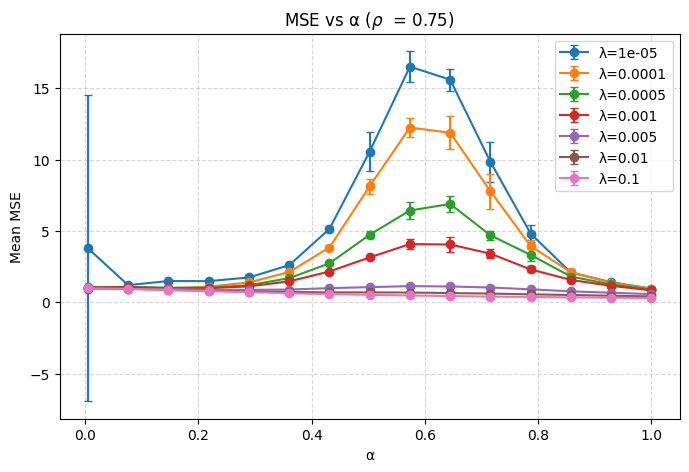

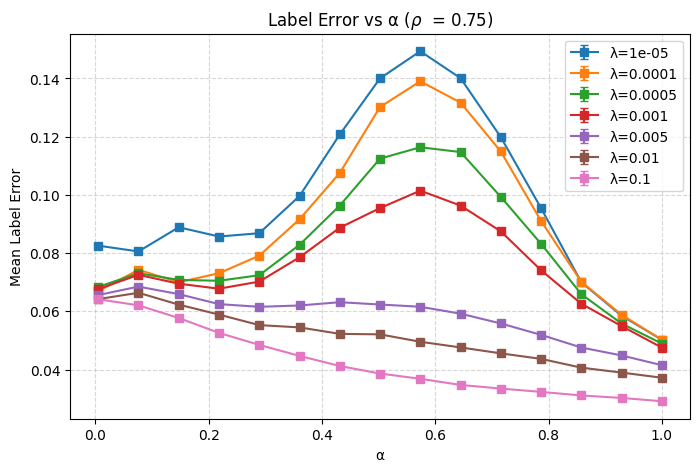

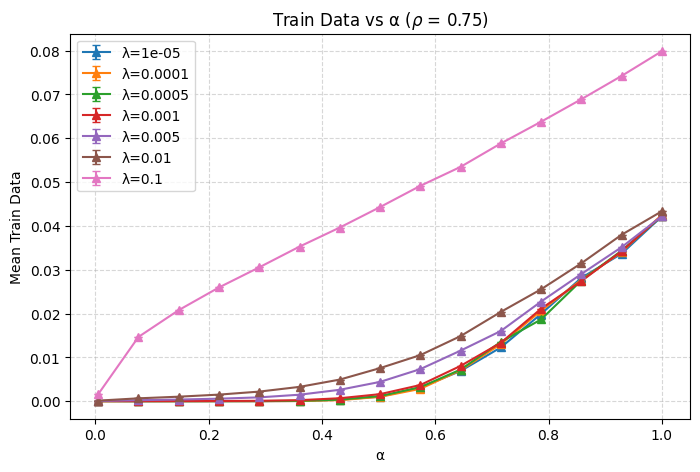

In [95]:
# --- Path to your local folder ---
base_path = f"../results/run_{run_id}/summary.csv"

# --- Read the CSV file ---
df = pd.read_csv(base_path, on_bad_lines='warn')
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- Plot MSE vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")  # Sort by alpha
    plt.errorbar(subset["alpha"], subset["MSE_mean"], yerr=subset.get("MSE_std", 0),
                 marker='o', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean MSE")
plt.title(rf"MSE vs α ($\rho$  = {config['rho'][0]})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Label Error vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["label_err_mean_noise"], yerr=subset.get("label_err_std_noise", 0),
                 marker='s', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Label Error")
plt.title(rf"Label Error vs α ($\rho$  = {config['rho'][0]})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for lam in sorted(df["lam"].unique()):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["train_data_mean"], yerr=subset.get("train_data_std", 0),
                 marker='^', capsize=3, label=f"λ={lam}")
plt.xlabel("α")
plt.ylabel("Mean Train Data")
plt.title(rf"Train Data vs α ($\rho$ = {config['rho'][0]})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Eigenvalue distributions per $\rho$

Found 15 W_Q files and 15 W_K files.

Processing Q matrices: W_Q_runs_0.pkl


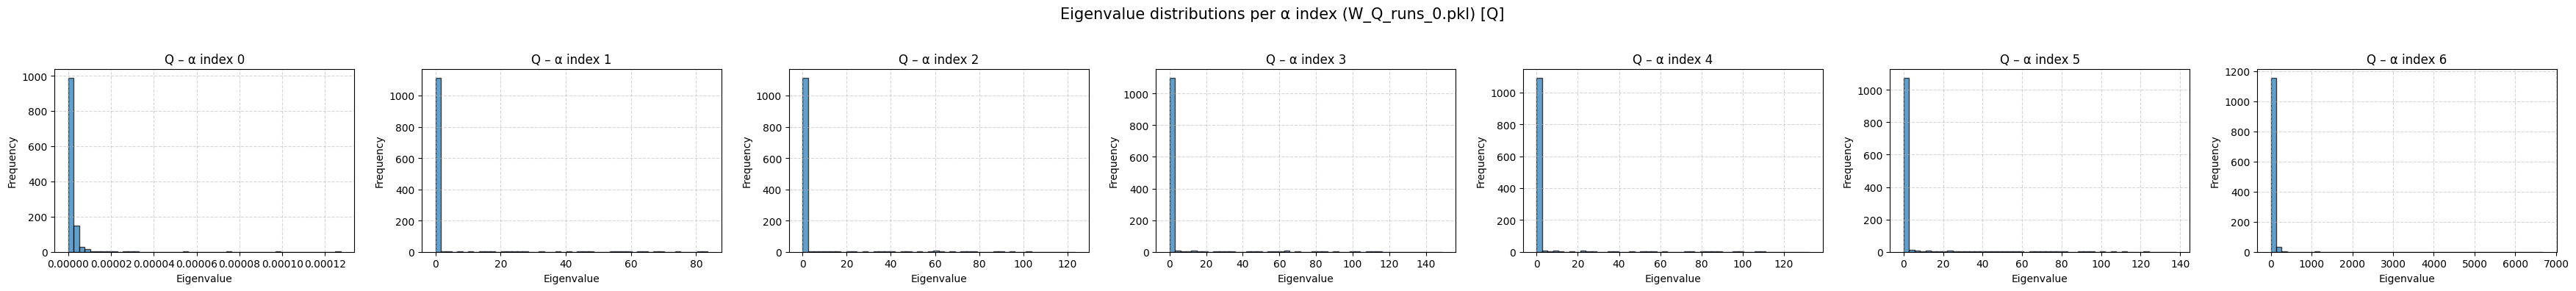


Processing Q matrices: W_Q_runs_1.pkl


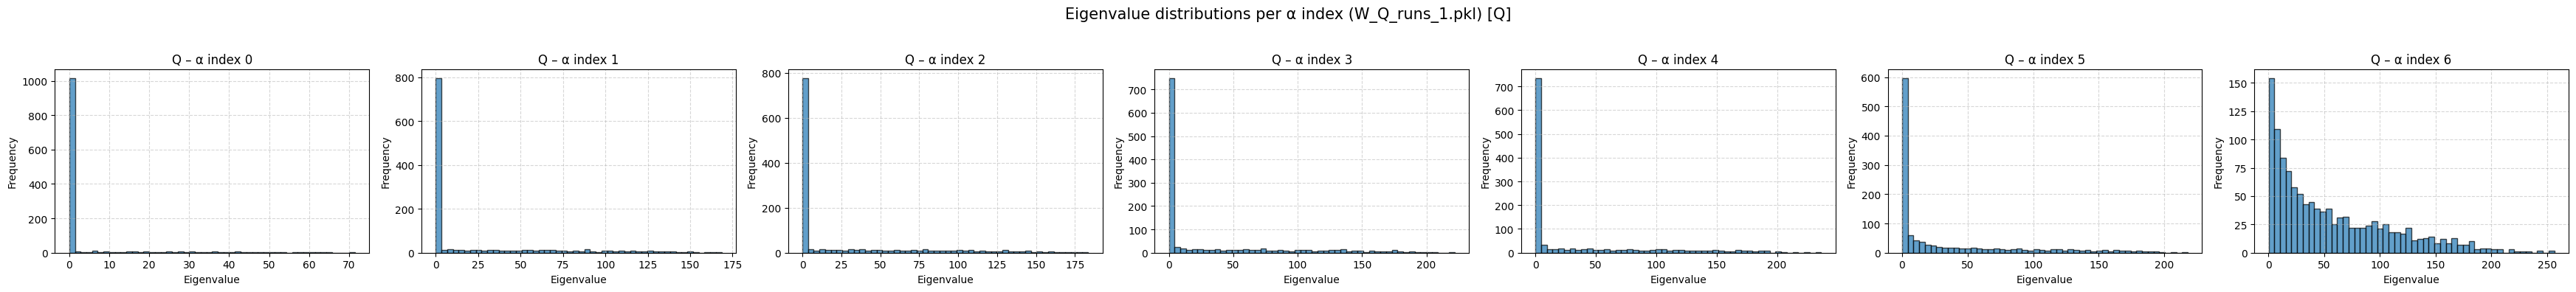


Processing Q matrices: W_Q_runs_10.pkl


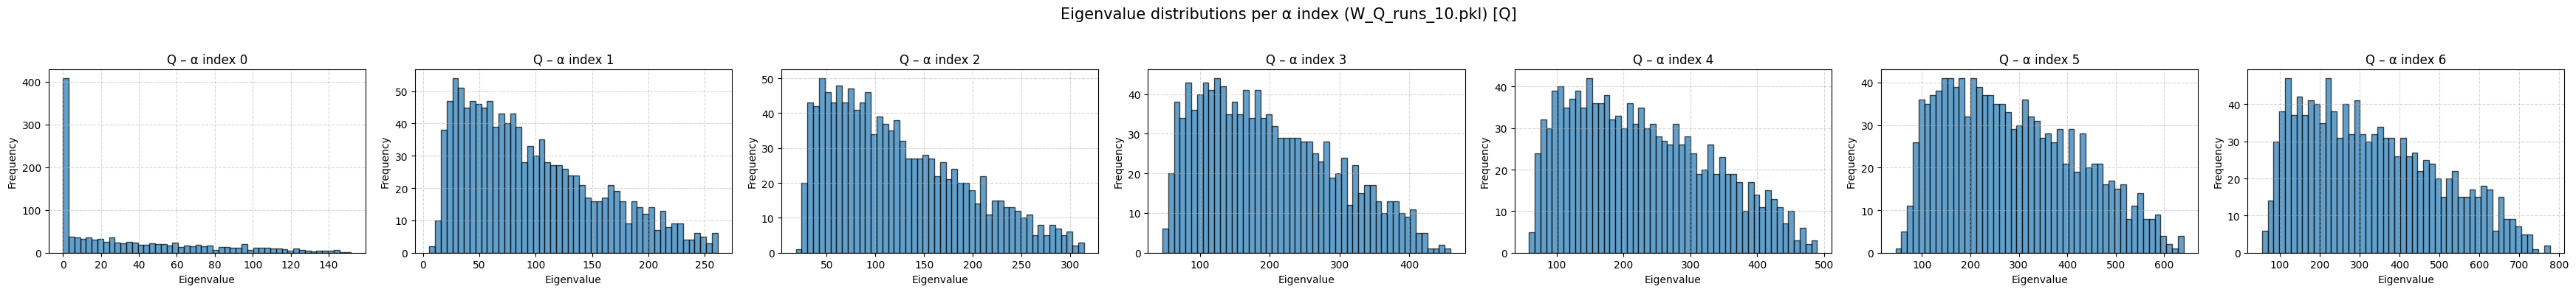


Processing Q matrices: W_Q_runs_11.pkl


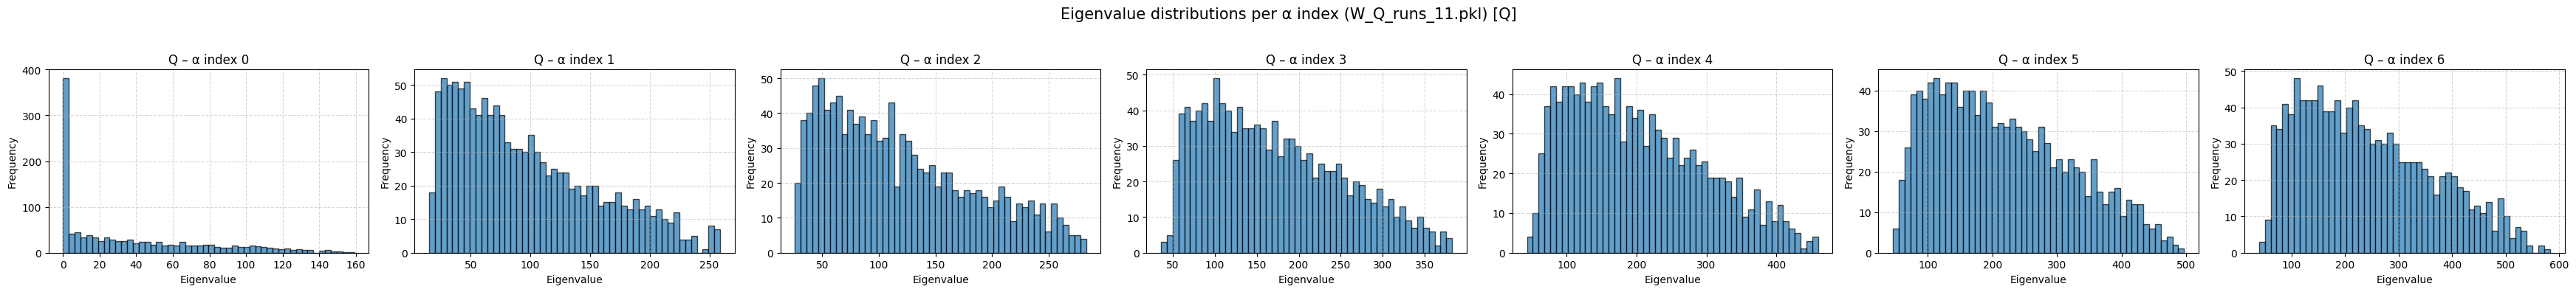


Processing Q matrices: W_Q_runs_12.pkl


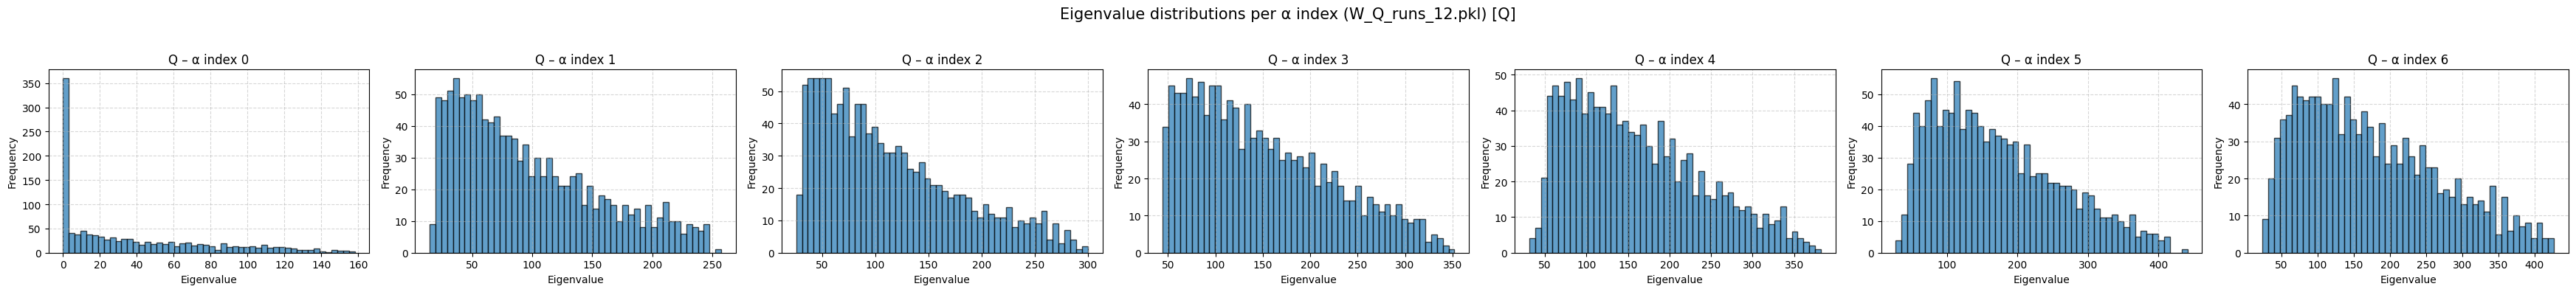


Processing Q matrices: W_Q_runs_13.pkl


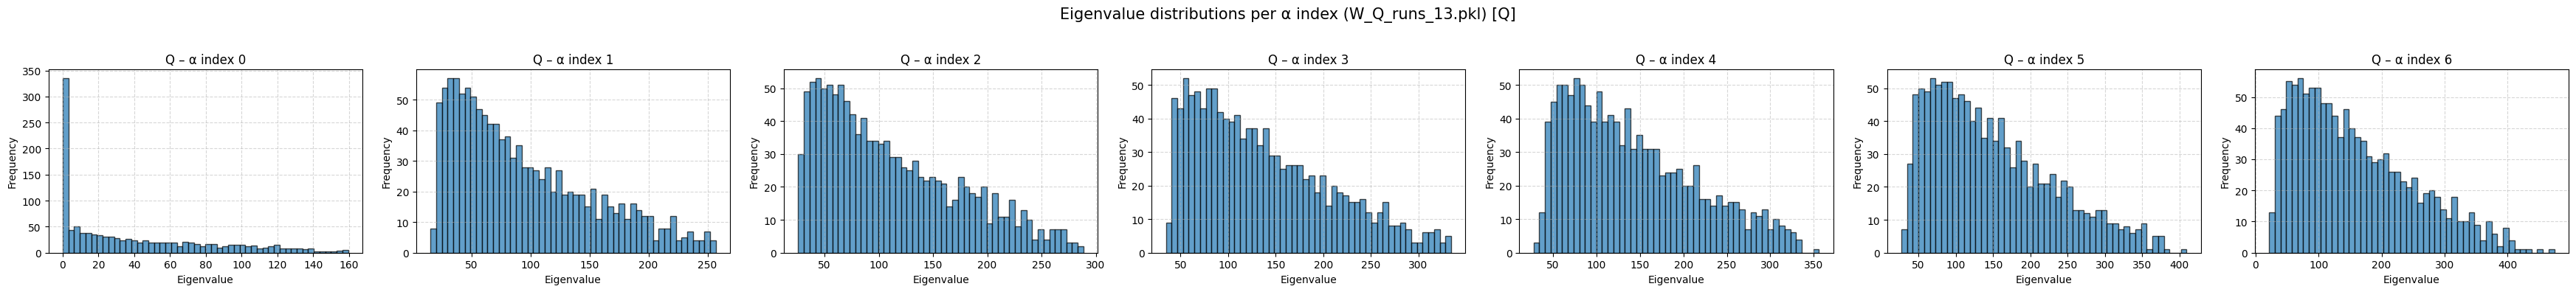


Processing Q matrices: W_Q_runs_14.pkl


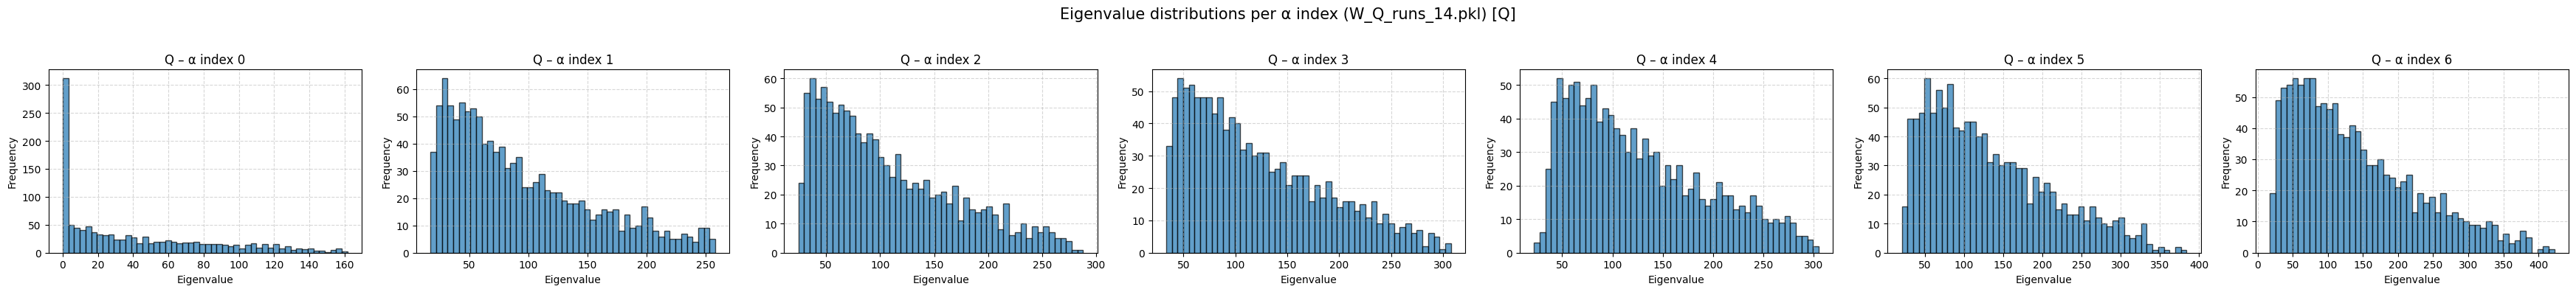


Processing Q matrices: W_Q_runs_2.pkl


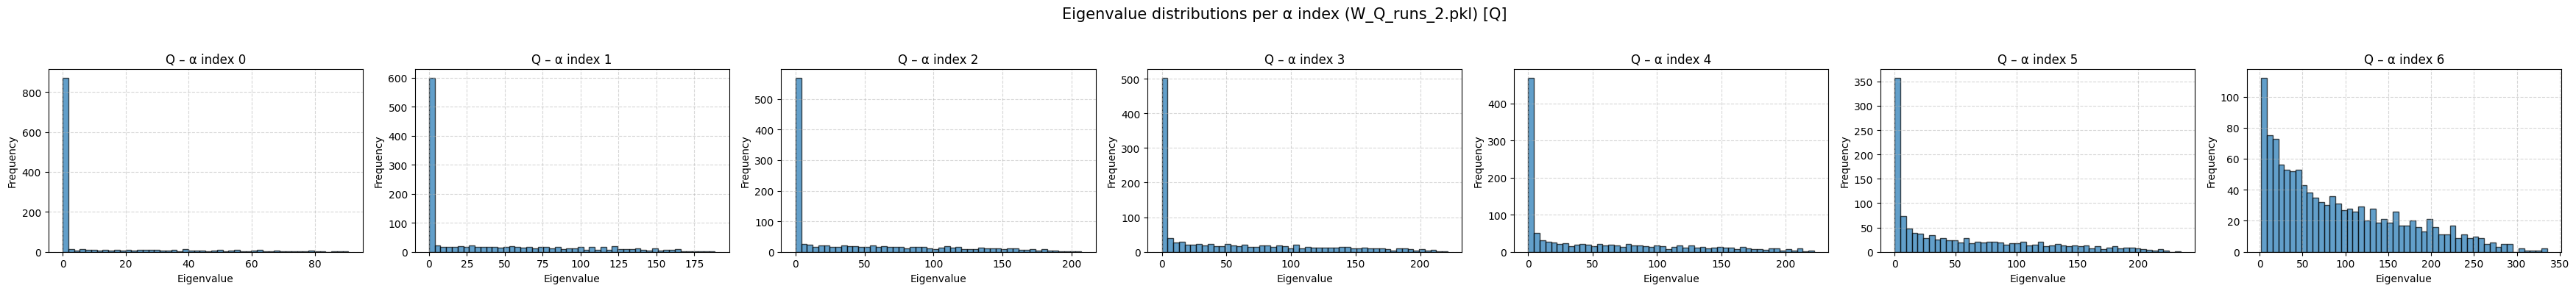


Processing Q matrices: W_Q_runs_3.pkl


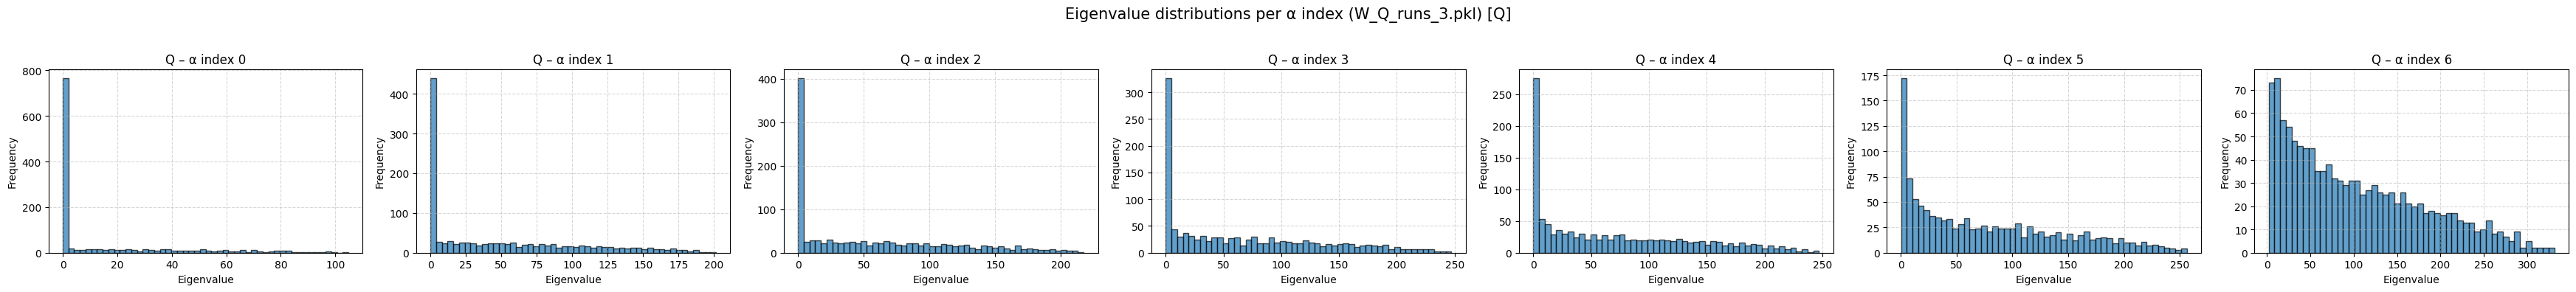


Processing Q matrices: W_Q_runs_4.pkl


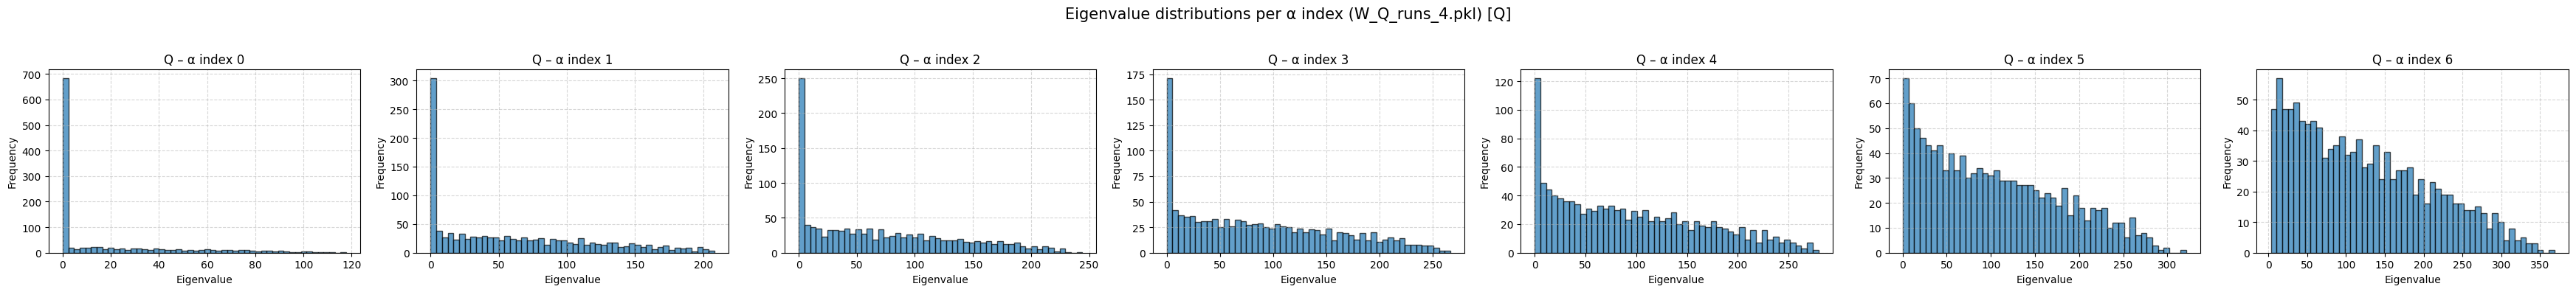


Processing Q matrices: W_Q_runs_5.pkl


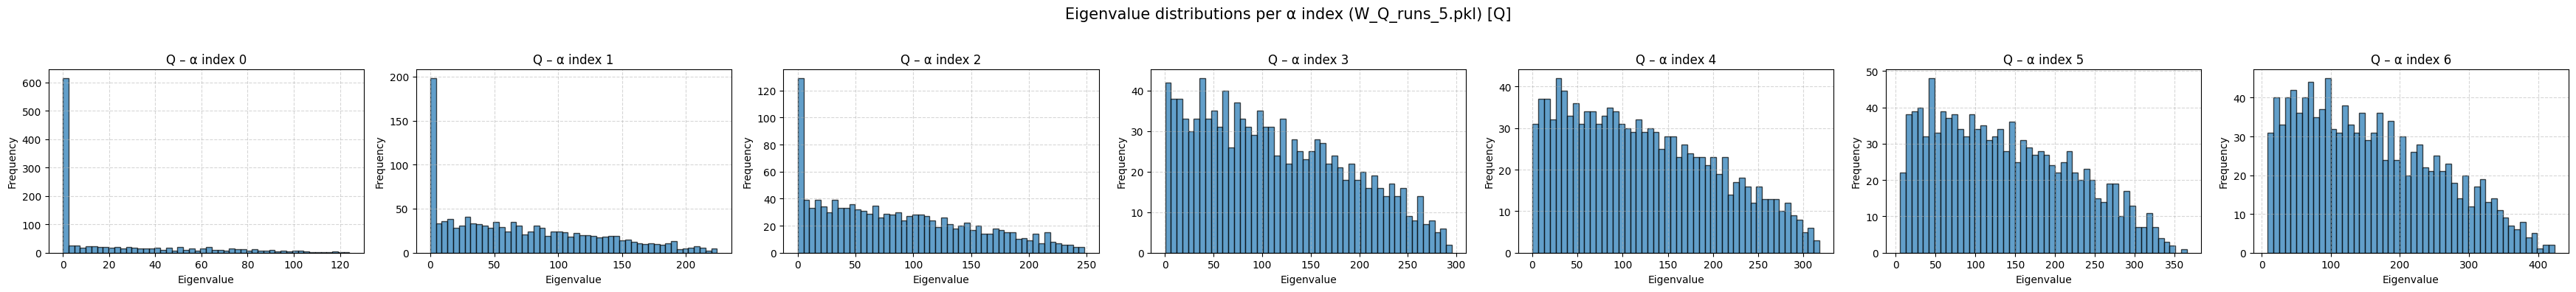


Processing Q matrices: W_Q_runs_6.pkl


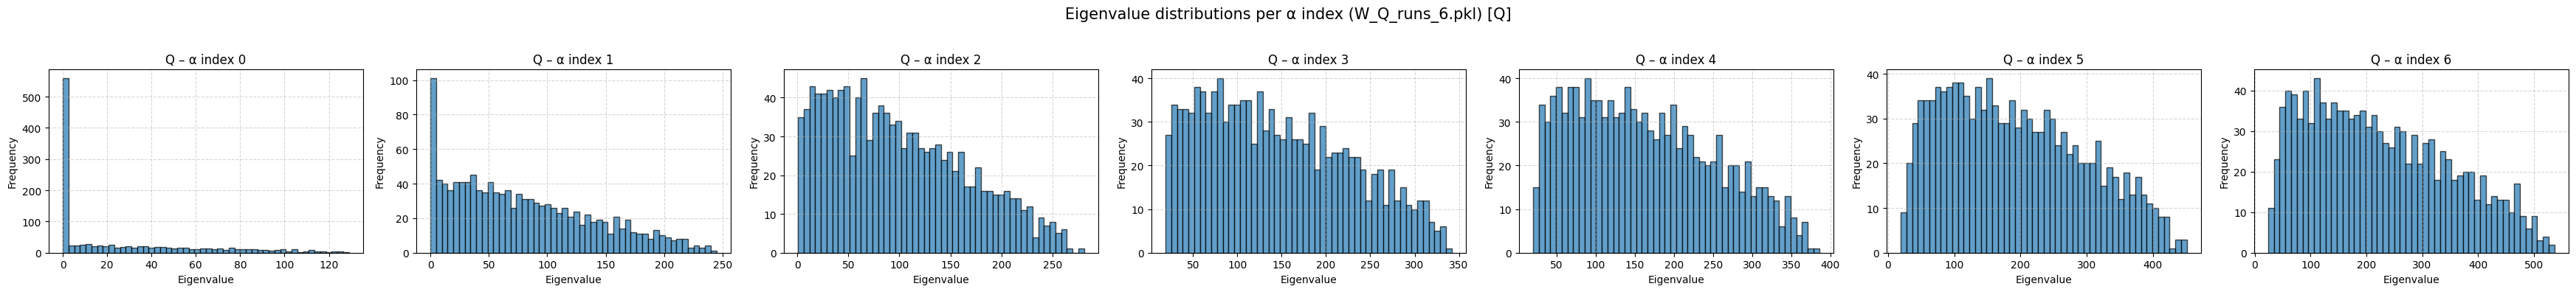


Processing Q matrices: W_Q_runs_7.pkl


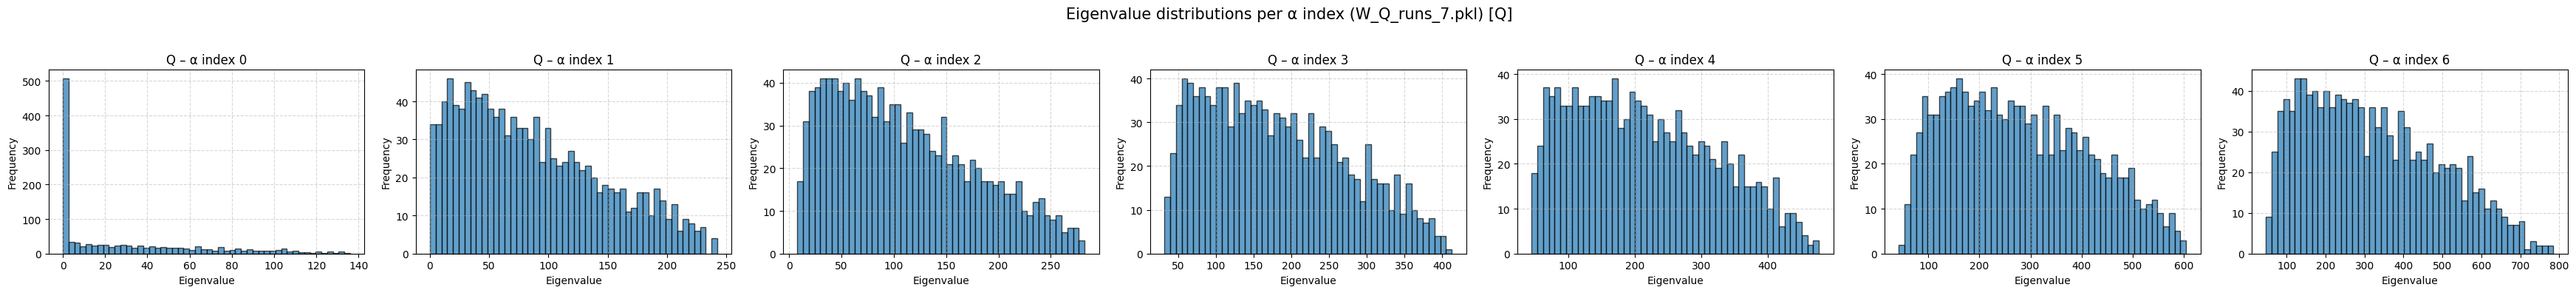


Processing Q matrices: W_Q_runs_8.pkl


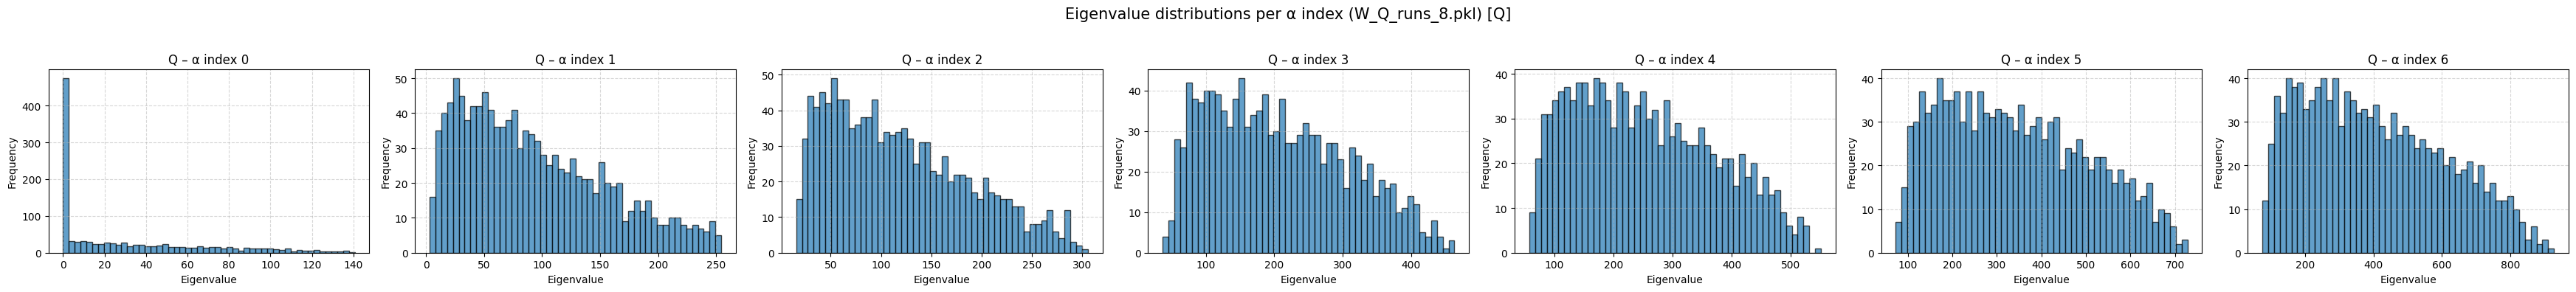


Processing Q matrices: W_Q_runs_9.pkl


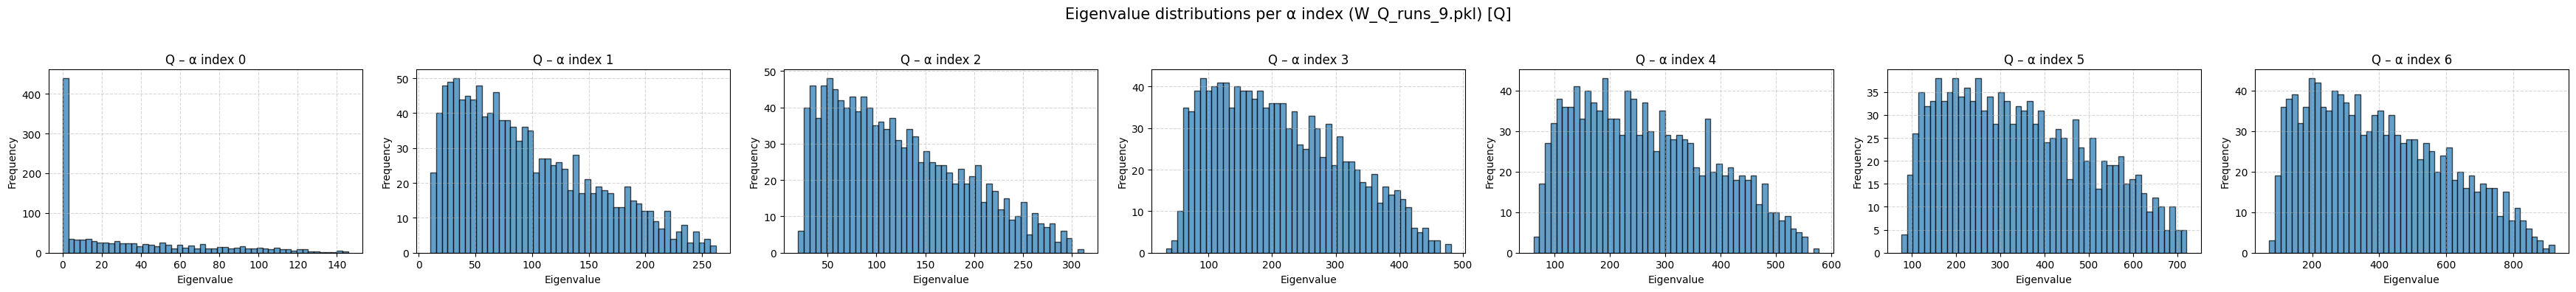


Processing K matrices: W_K_runs_0.pkl


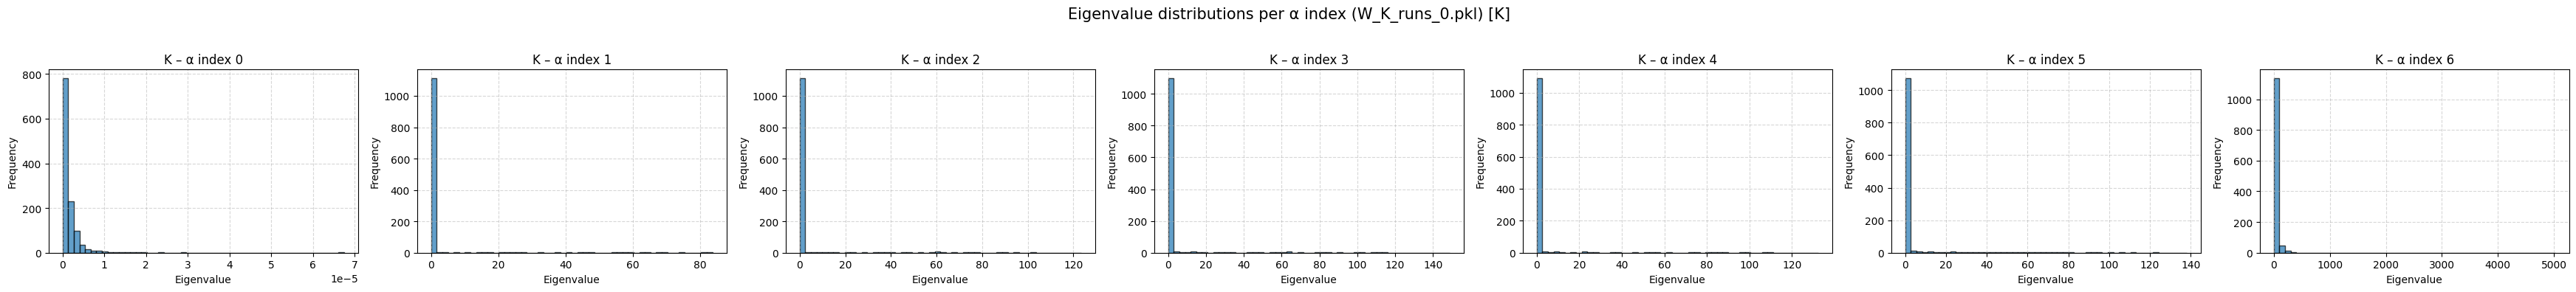


Processing K matrices: W_K_runs_1.pkl


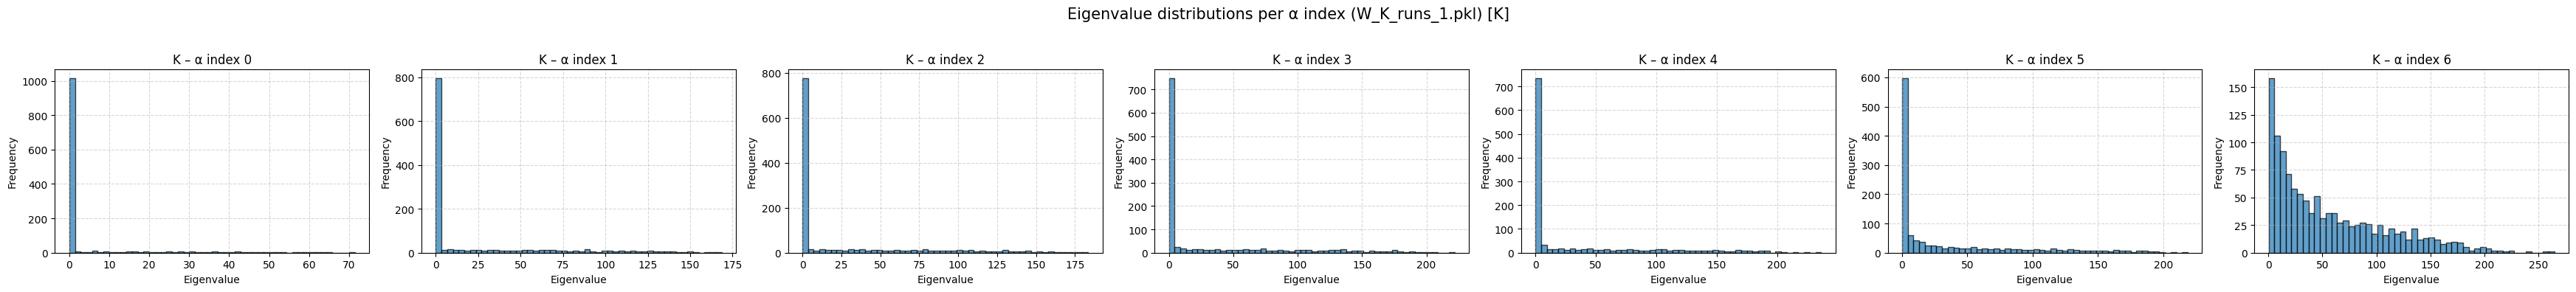


Processing K matrices: W_K_runs_10.pkl


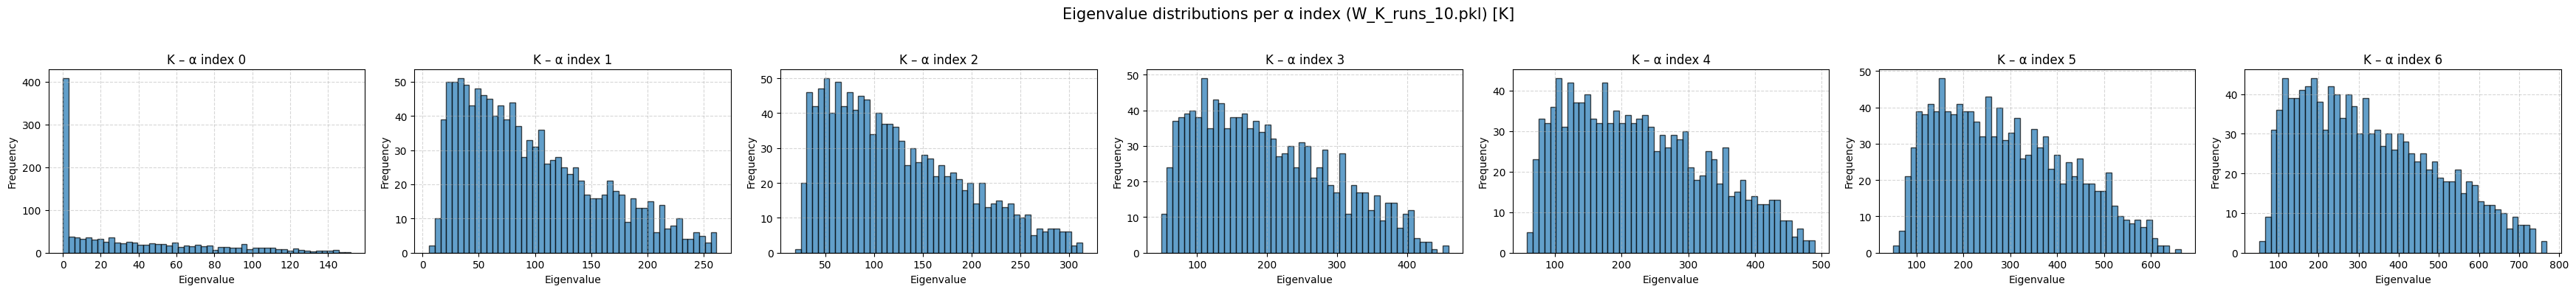


Processing K matrices: W_K_runs_11.pkl


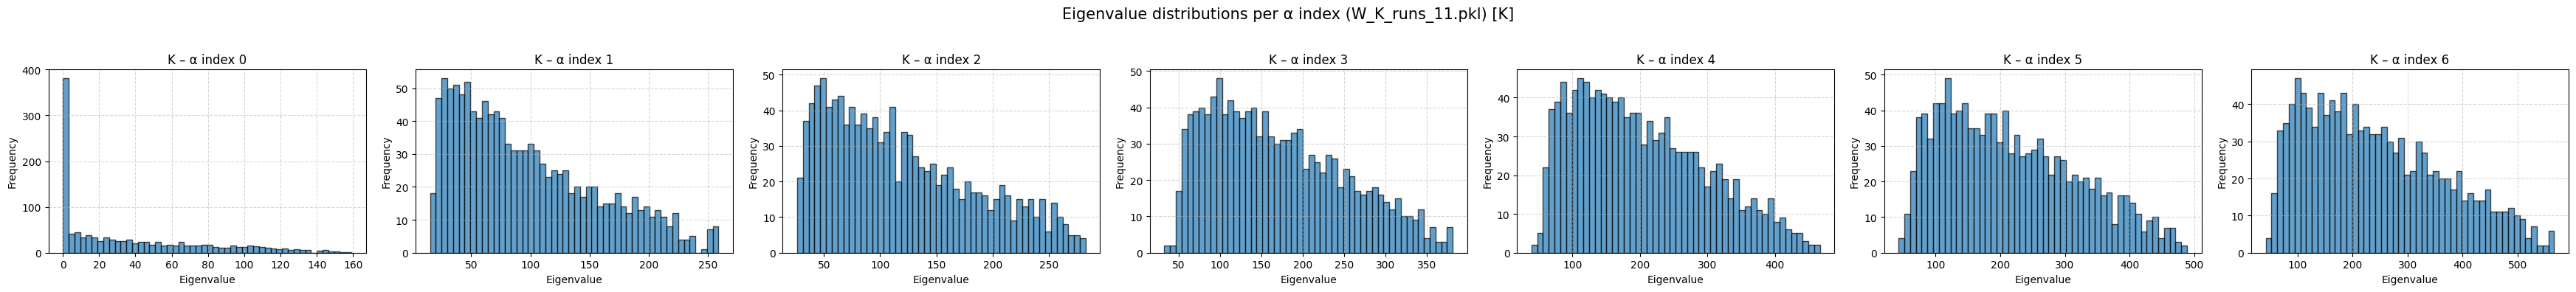


Processing K matrices: W_K_runs_12.pkl


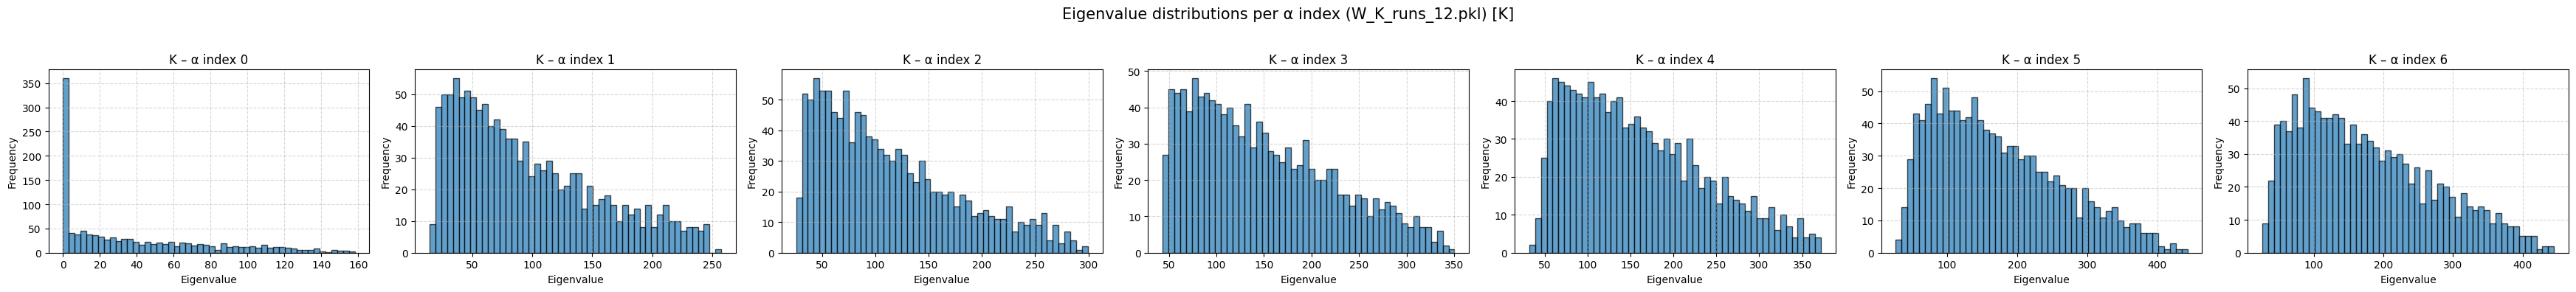


Processing K matrices: W_K_runs_13.pkl


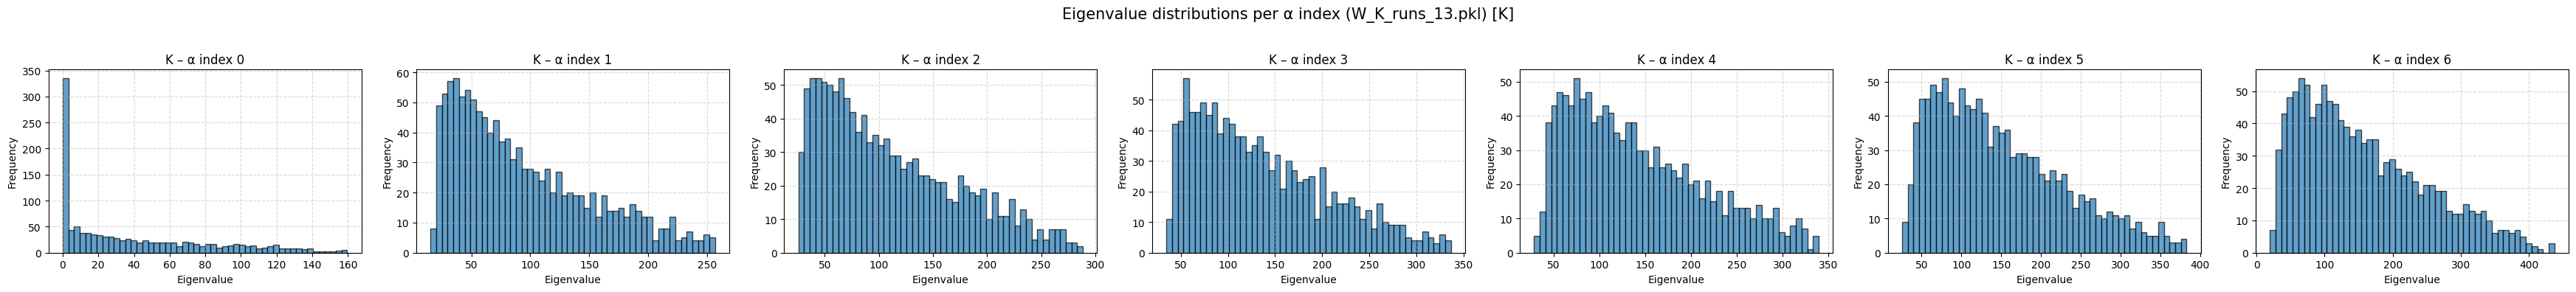


Processing K matrices: W_K_runs_14.pkl


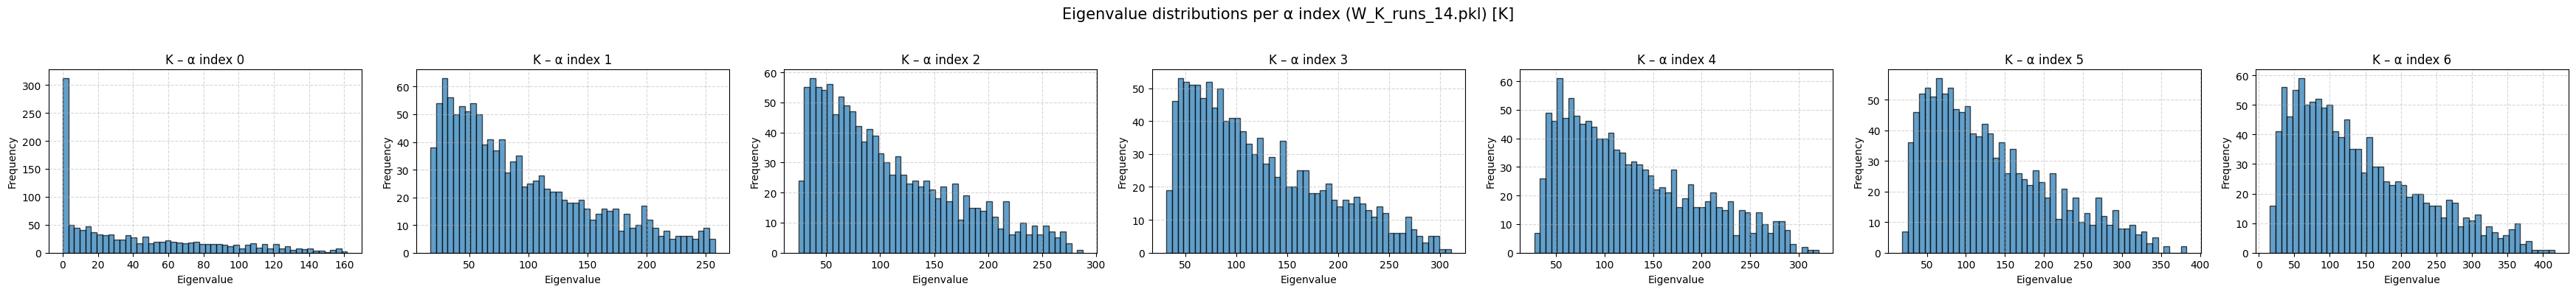


Processing K matrices: W_K_runs_2.pkl


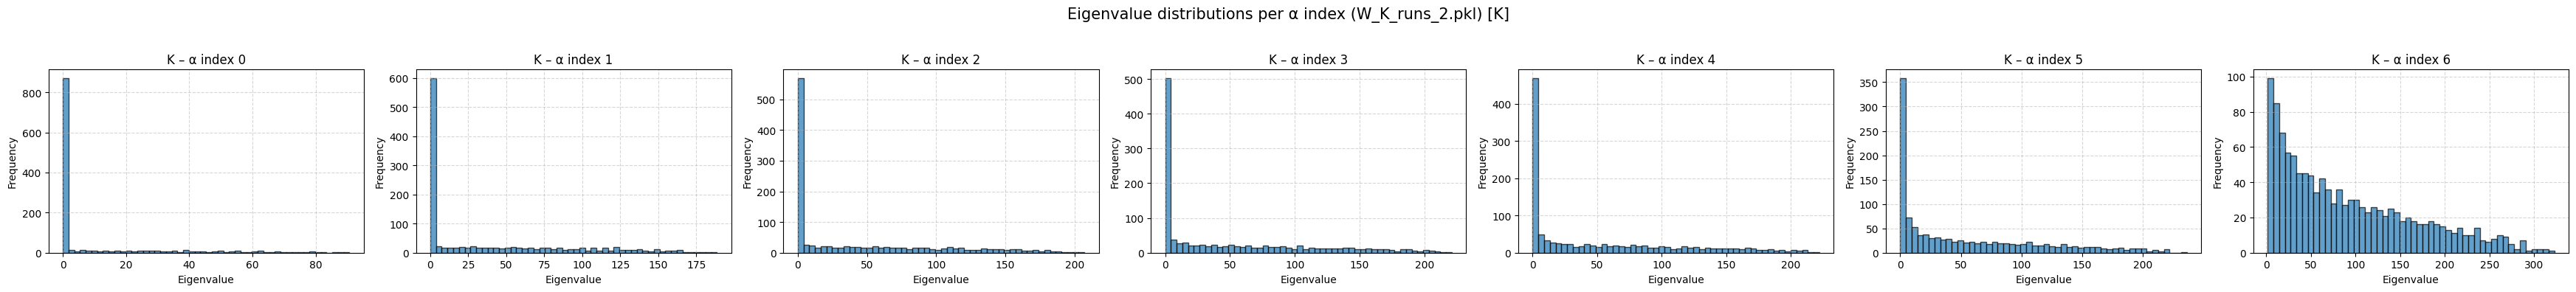


Processing K matrices: W_K_runs_3.pkl


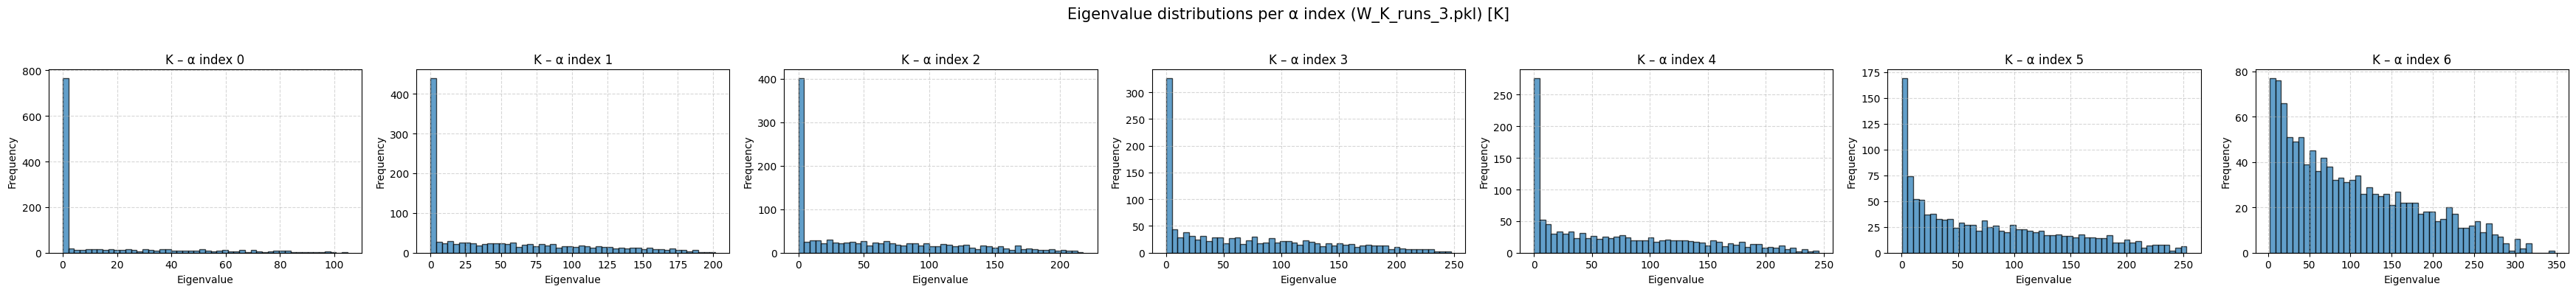


Processing K matrices: W_K_runs_4.pkl


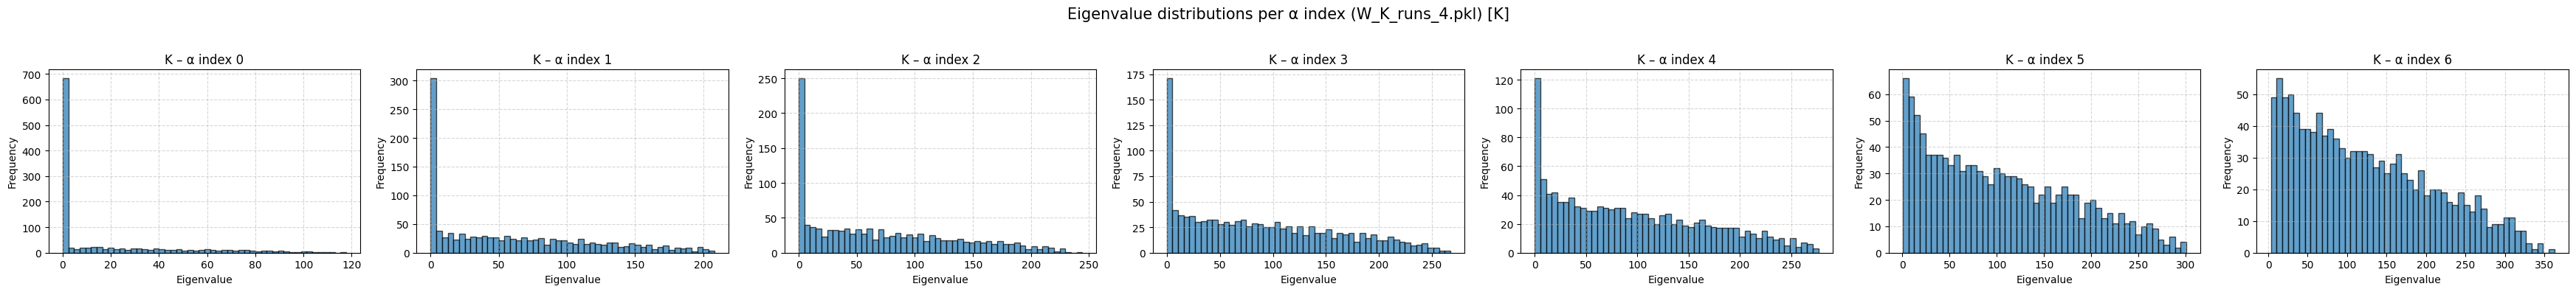


Processing K matrices: W_K_runs_5.pkl


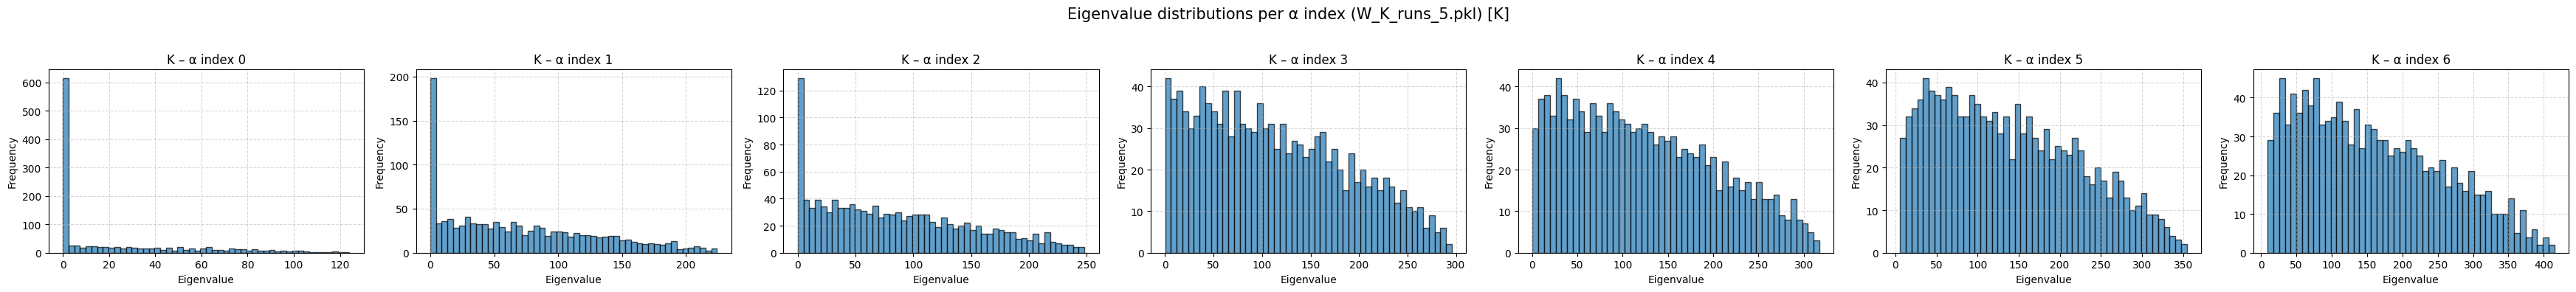


Processing K matrices: W_K_runs_6.pkl


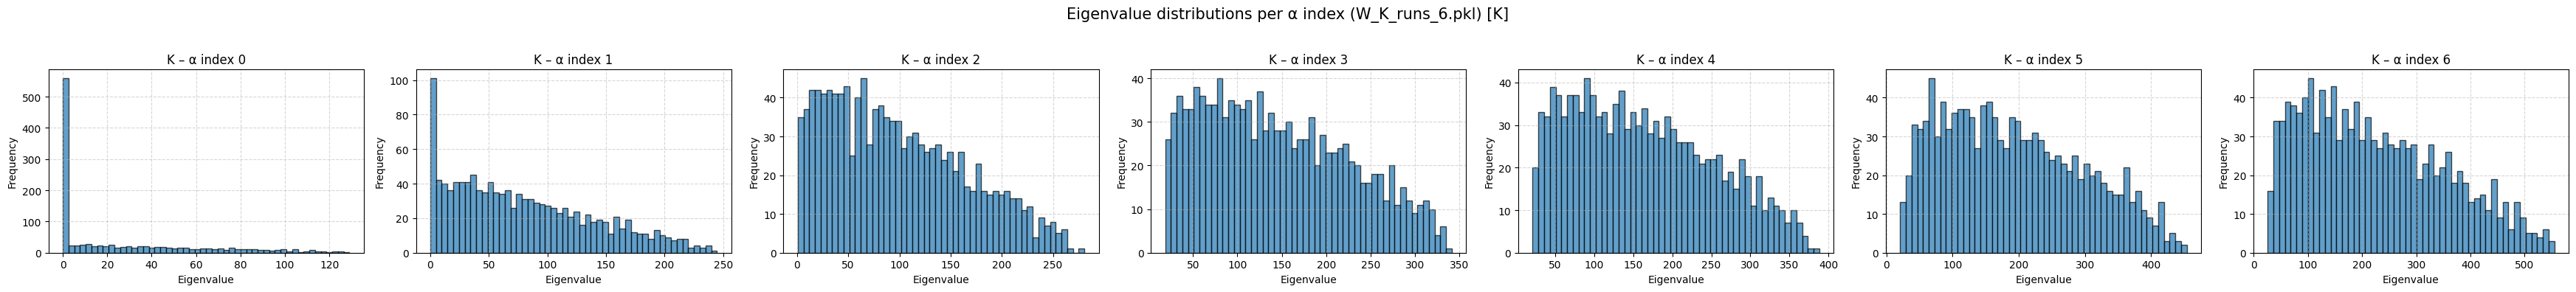


Processing K matrices: W_K_runs_7.pkl


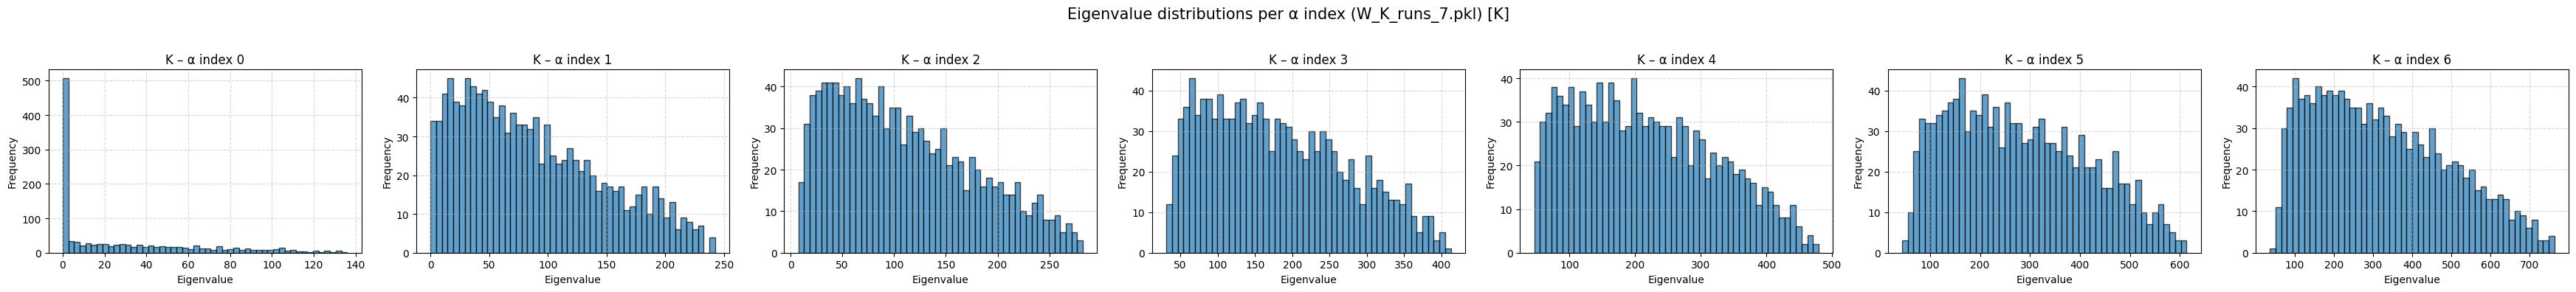


Processing K matrices: W_K_runs_8.pkl


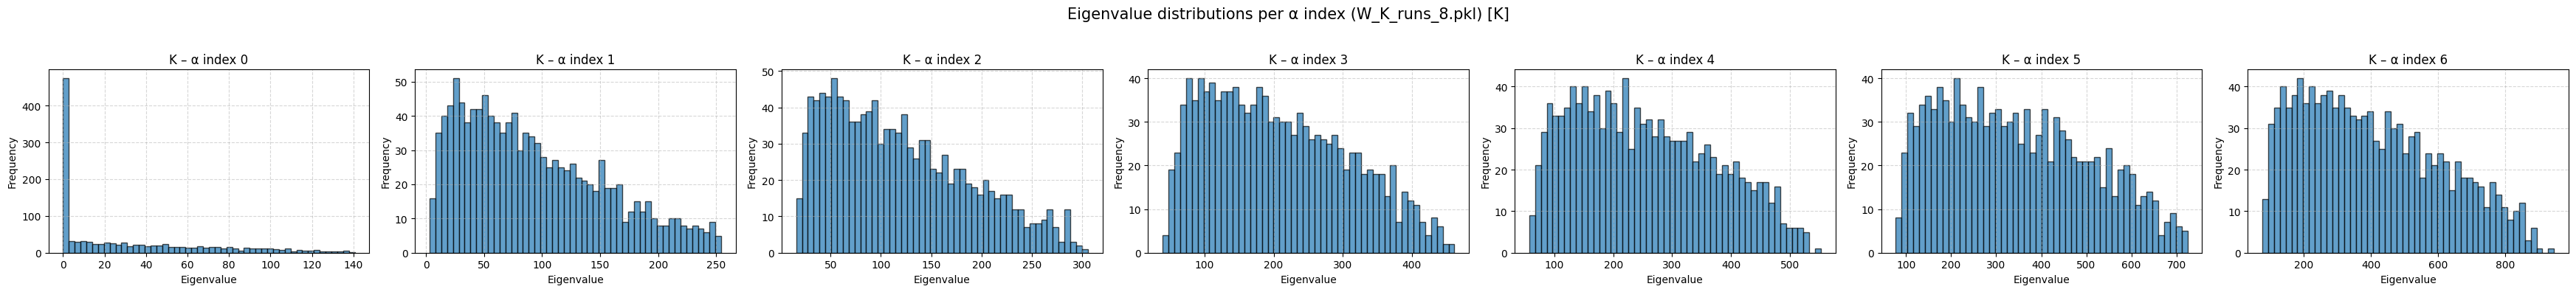


Processing K matrices: W_K_runs_9.pkl


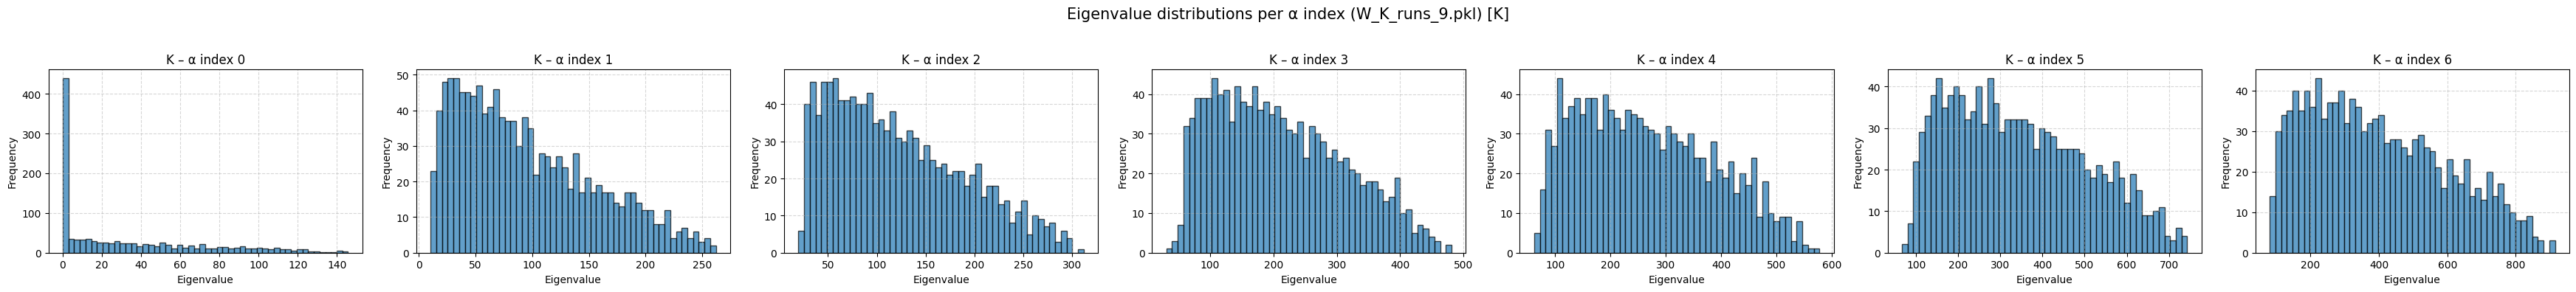

In [96]:
# --- Path to your results directory ---
run_dir = f"../results/run_{run_id}"  # replace with your run_id

# --- Find all pickle files ---
pkl_Q_files = sorted(glob.glob(os.path.join(run_dir, "W_Q_runs_*.pkl")))
pkl_K_files = sorted(glob.glob(os.path.join(run_dir, "W_K_runs_*.pkl")))

print(f"Found {len(pkl_Q_files)} W_Q files and {len(pkl_K_files)} W_K files.")

# --- Helper function to plot a given W_* file ---
def plot_W_spectra(pkl_file, label_type="Q"):
    with open(pkl_file, "rb") as f:
        W_runs_all = pickle.load(f)  # List of W lists per α index

    num_alpha = len(W_runs_all)
    fig, axes = plt.subplots(1, num_alpha, figsize=(5*num_alpha, 4), squeeze=False)

    for i, W_list in enumerate(W_runs_all):
        all_eigvals_i = []
        for W in W_list:
            eigvals = np.linalg.eigvalsh(W @ W.T)
            all_eigvals_i.extend(eigvals)

        all_eigvals_i = np.array(all_eigvals_i)
        ax = axes[0, i]
        ax.hist(all_eigvals_i, bins=50, alpha=0.7, edgecolor='black')
        ax.set_xlabel("Eigenvalue")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{label_type} – α index {i}")
        ax.grid(True, linestyle="--", alpha=0.5)

    fig.suptitle(f"Eigenvalue distributions per α index ({os.path.basename(pkl_file)}) [{label_type}]", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# --- Plot all W_Q_runs_*.pkl files ---
for pkl_file in pkl_Q_files:
    print(f"\nProcessing Q matrices: {os.path.basename(pkl_file)}")
    plot_W_spectra(pkl_file, label_type="Q")

# --- Plot all W_K_runs_*.pkl files ---
for pkl_file in pkl_K_files:
    print(f"\nProcessing K matrices: {os.path.basename(pkl_file)}")
    plot_W_spectra(pkl_file, label_type="K")


Comparing Q vs K for W_Q_runs_0.pkl


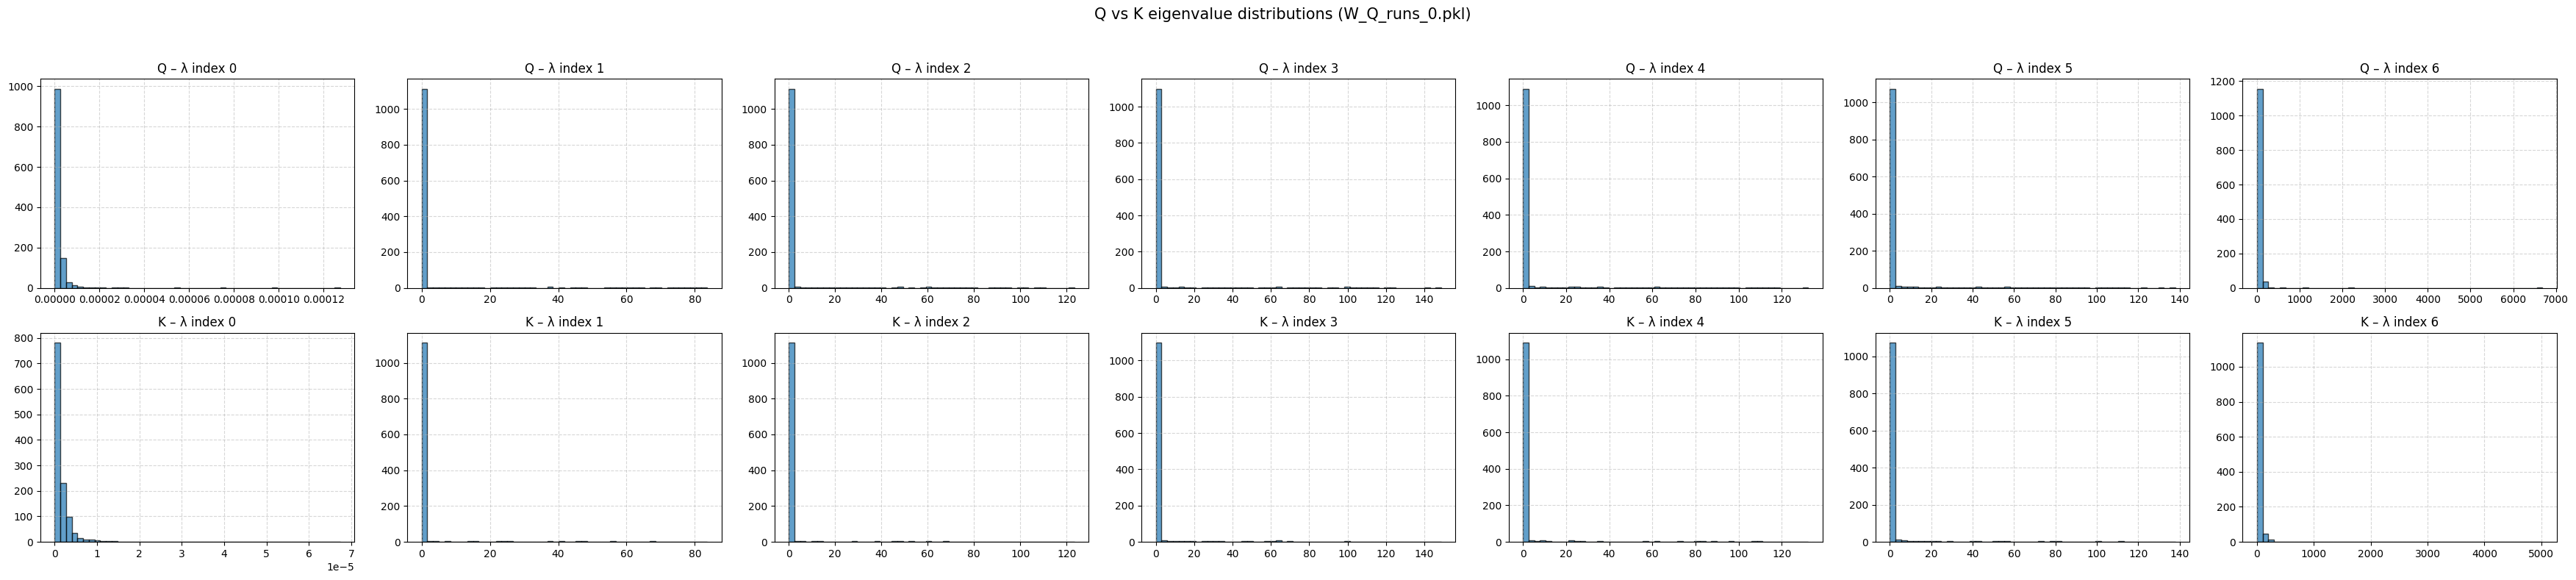


Comparing Q vs K for W_Q_runs_1.pkl


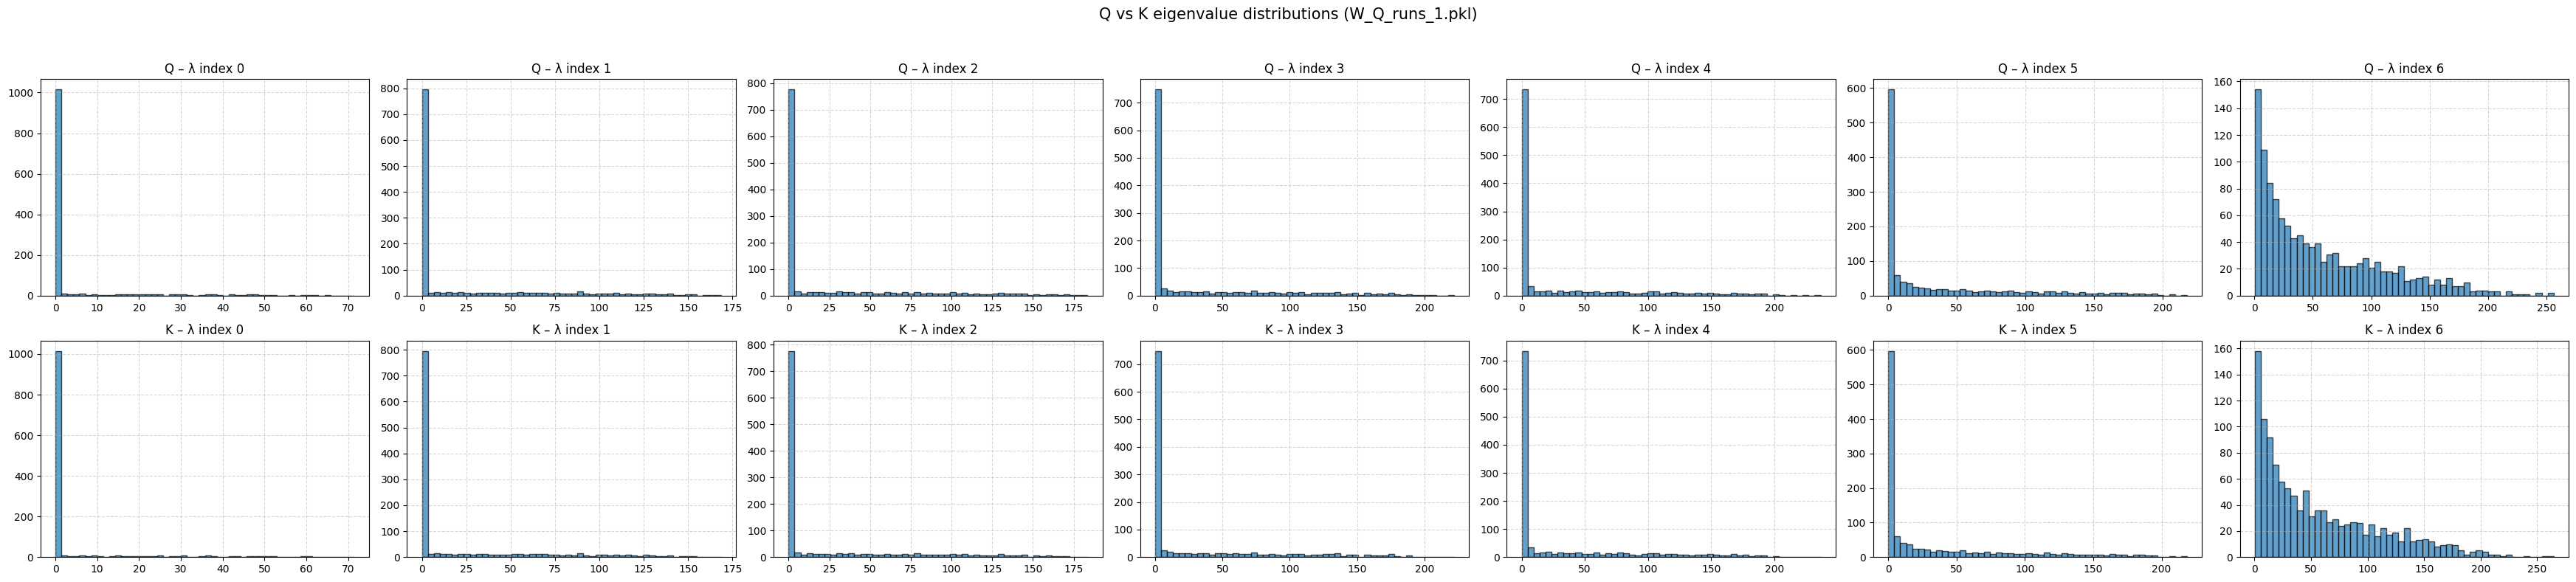


Comparing Q vs K for W_Q_runs_10.pkl


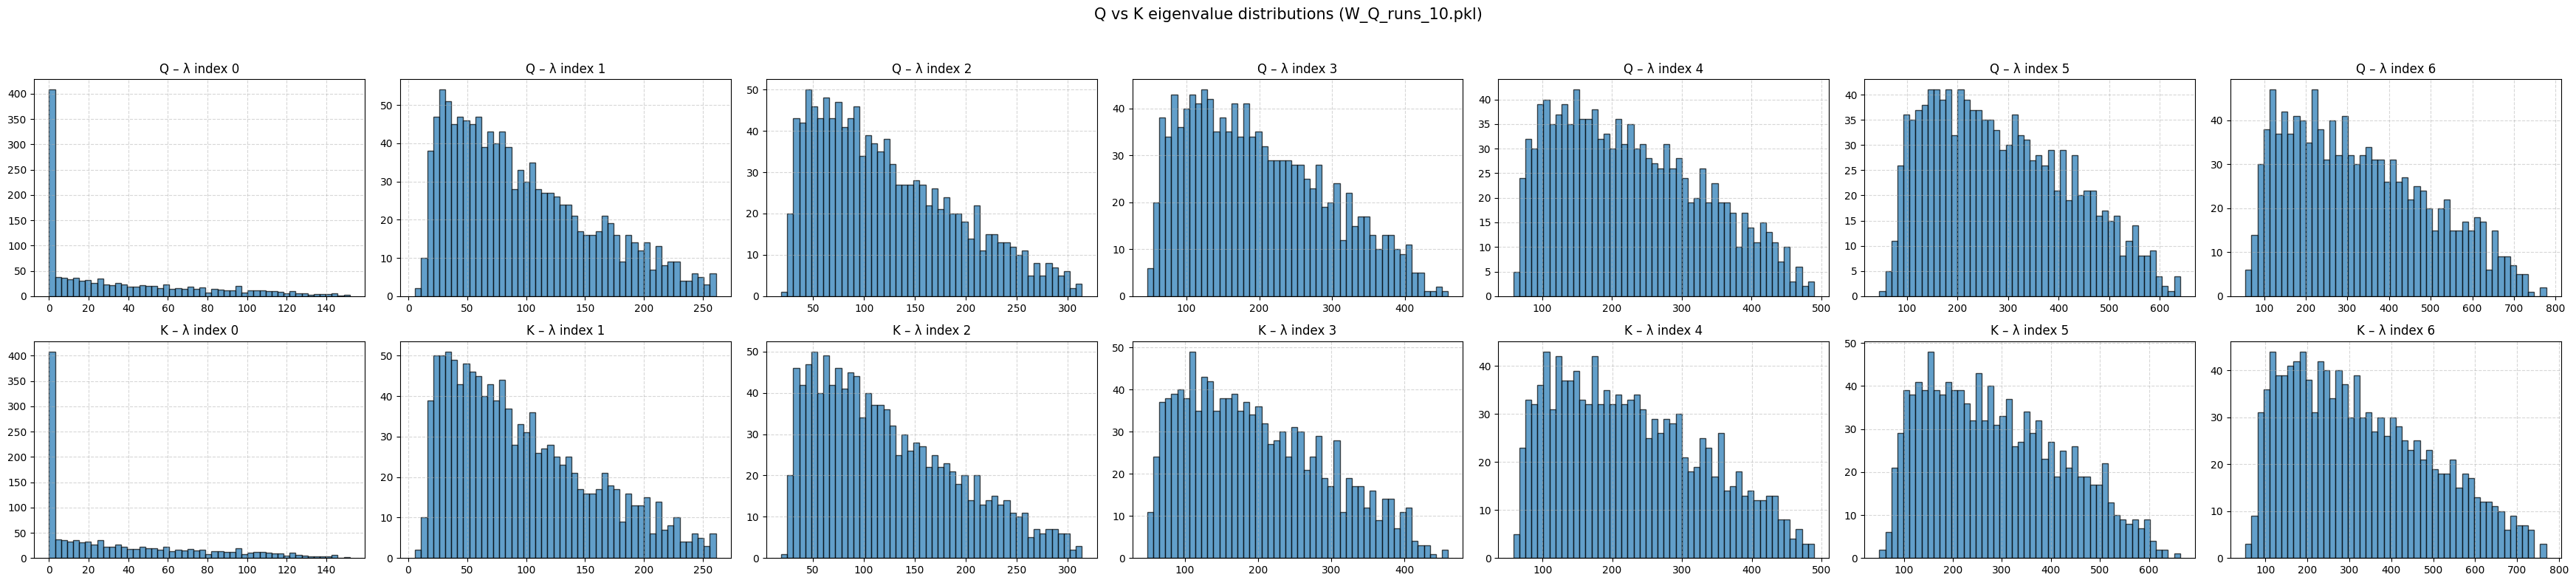


Comparing Q vs K for W_Q_runs_11.pkl


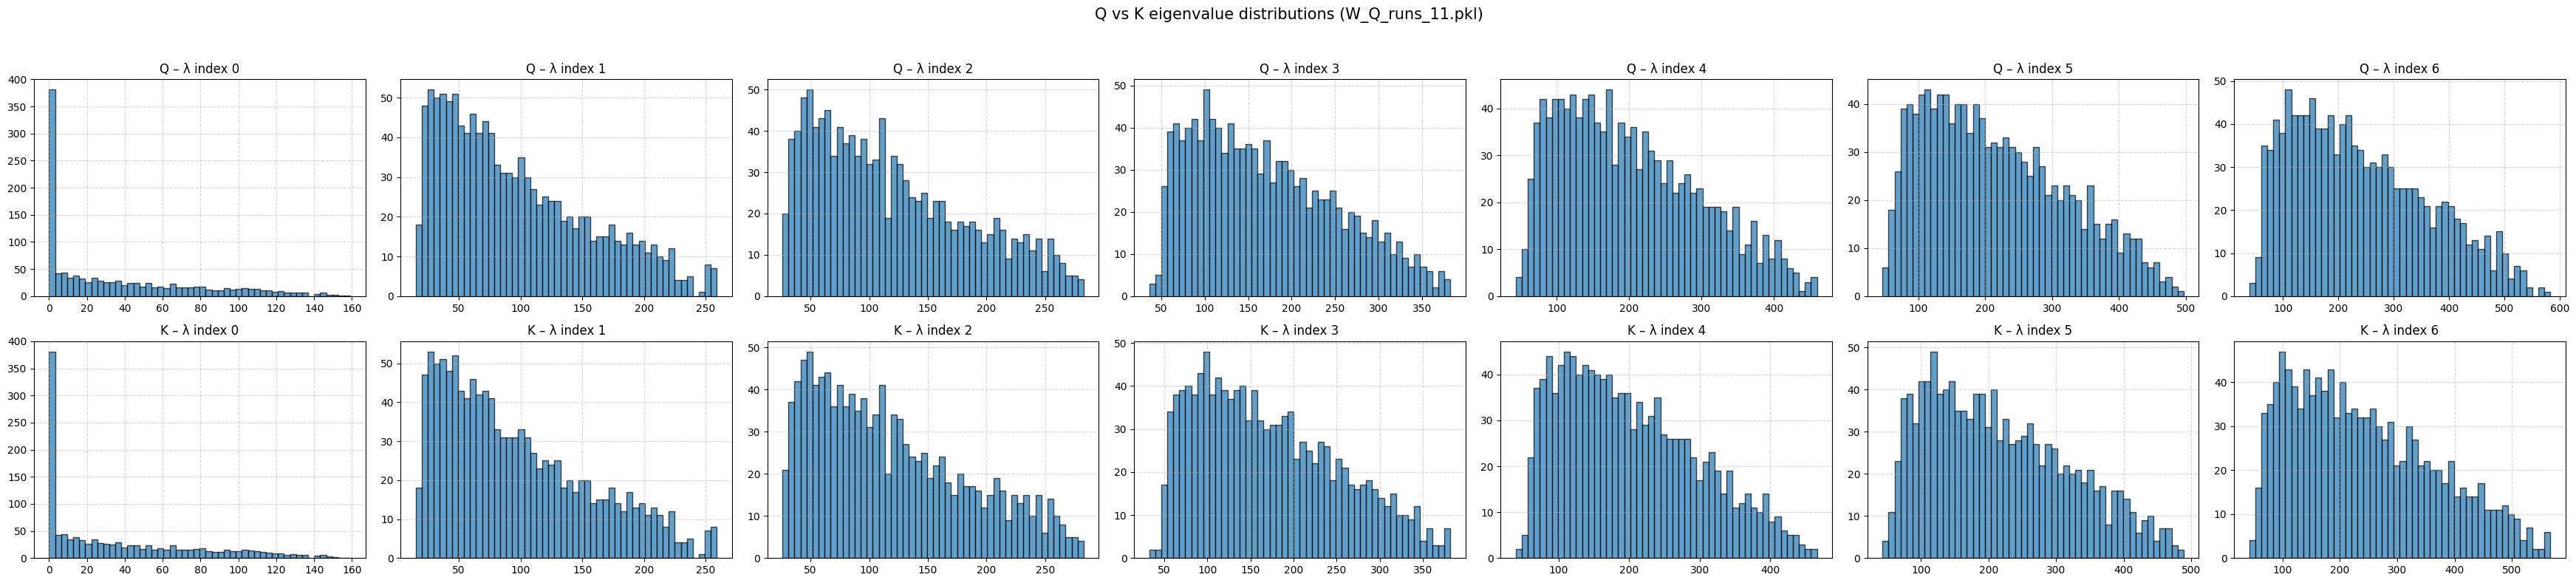


Comparing Q vs K for W_Q_runs_12.pkl


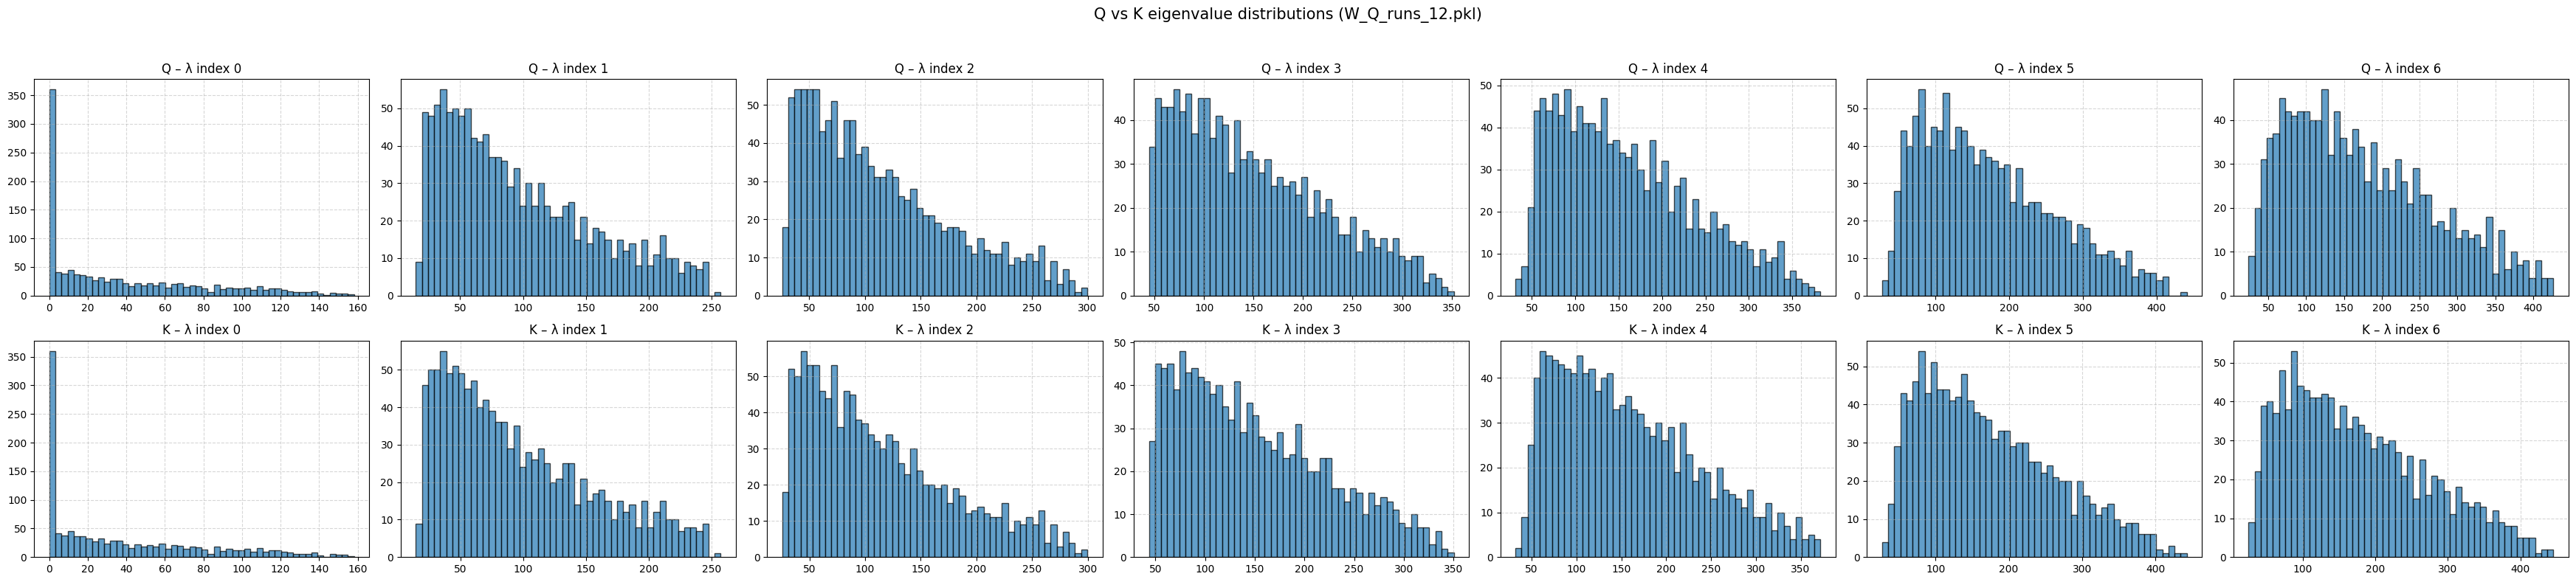


Comparing Q vs K for W_Q_runs_13.pkl


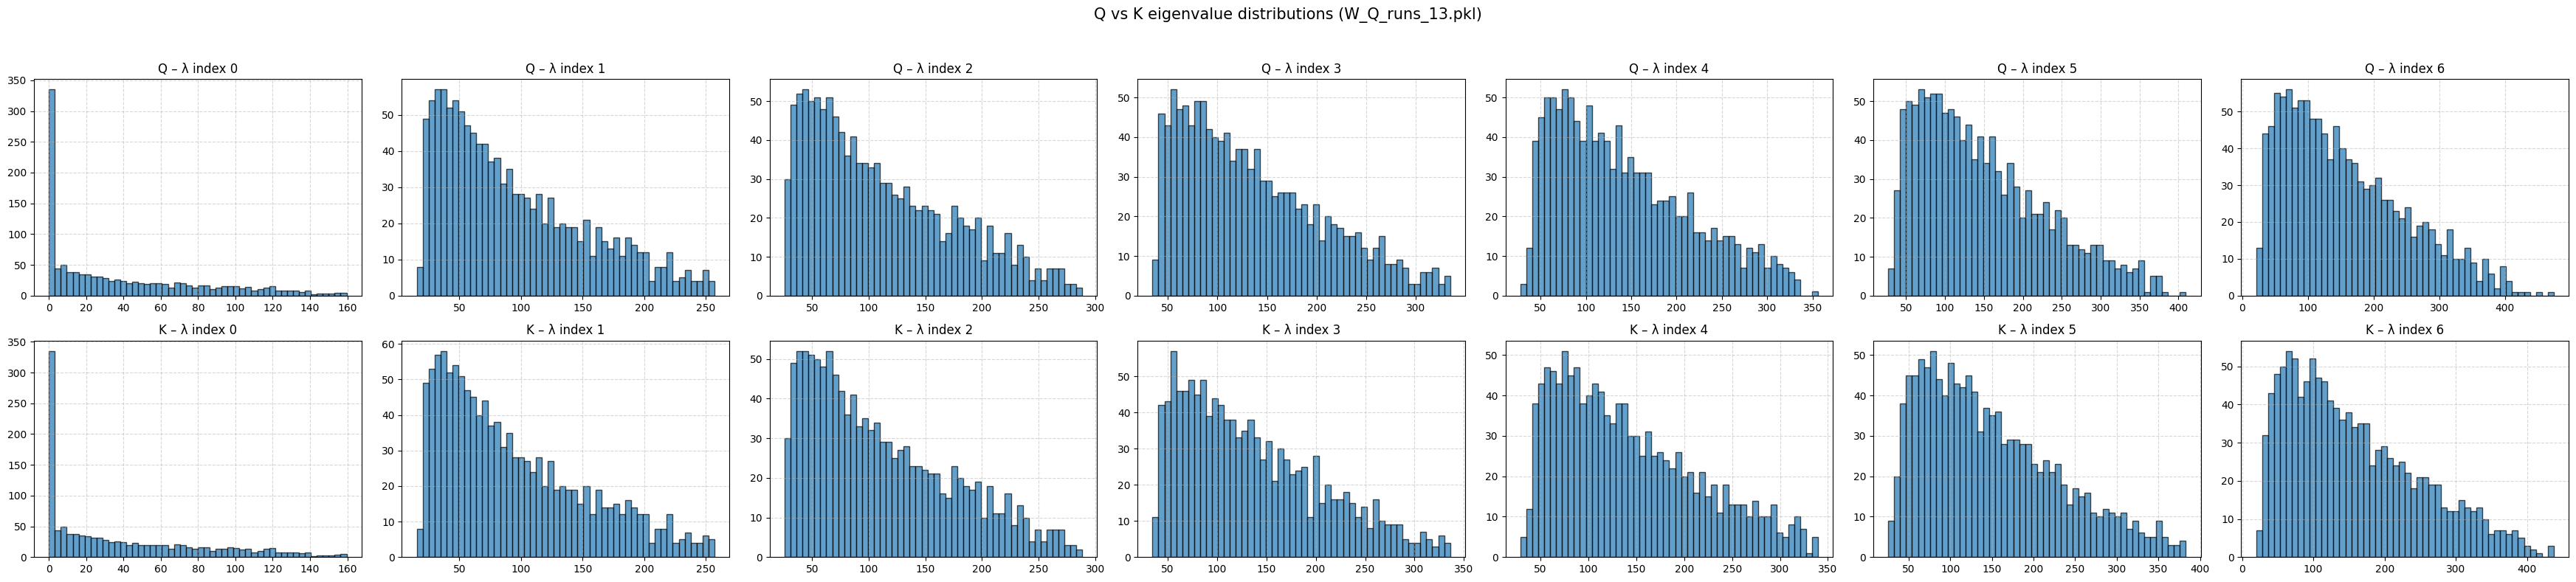


Comparing Q vs K for W_Q_runs_14.pkl


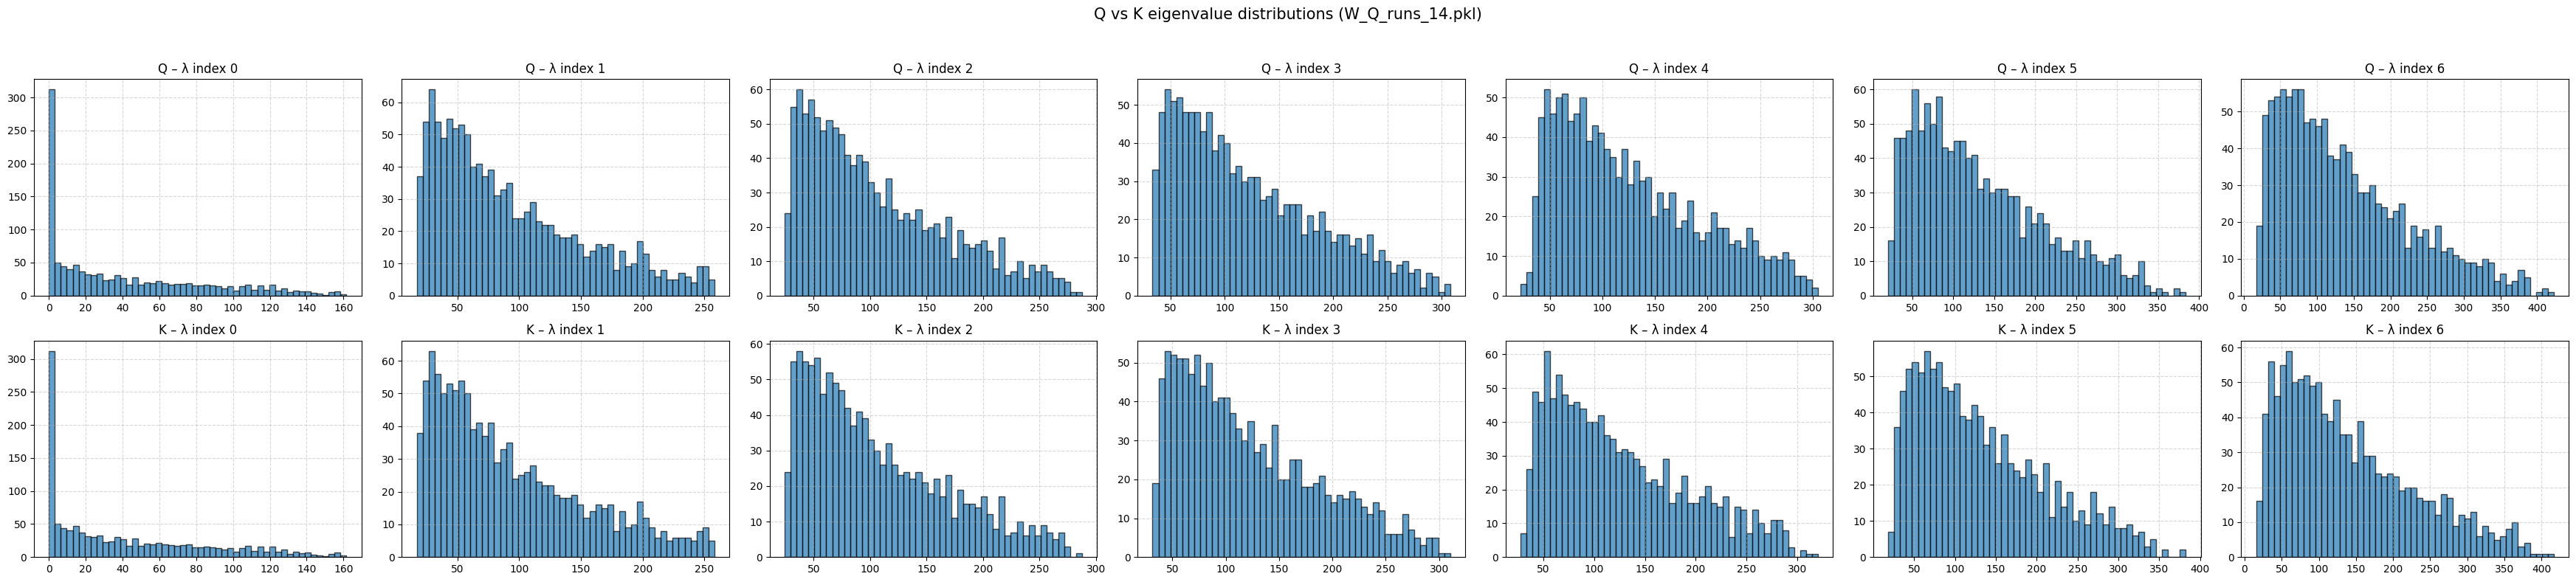


Comparing Q vs K for W_Q_runs_2.pkl


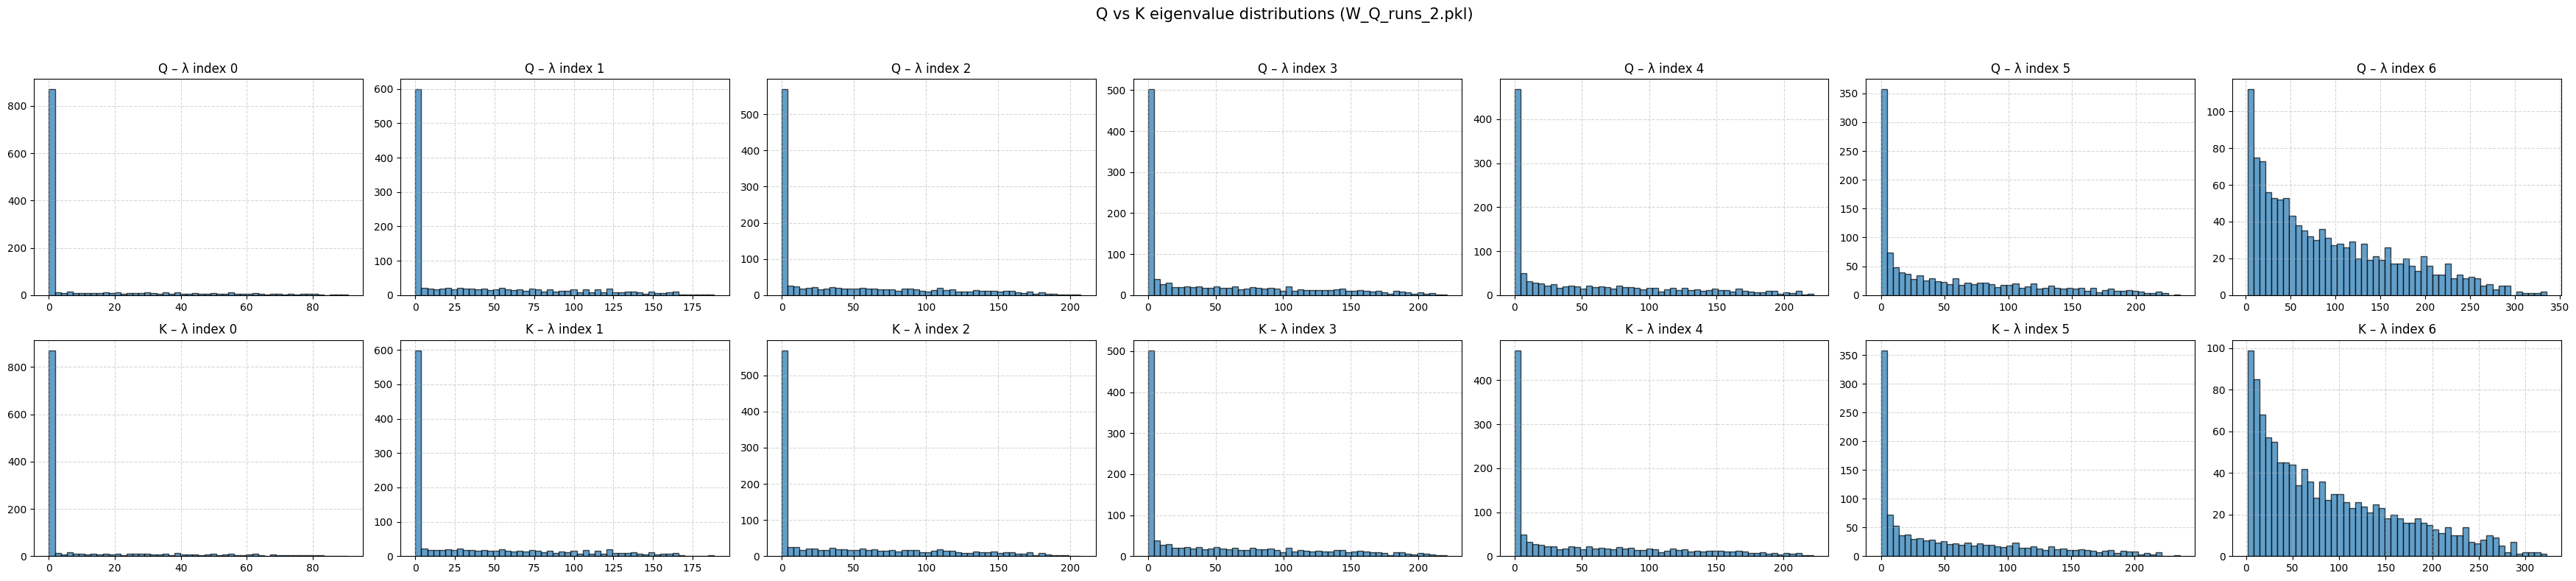


Comparing Q vs K for W_Q_runs_3.pkl


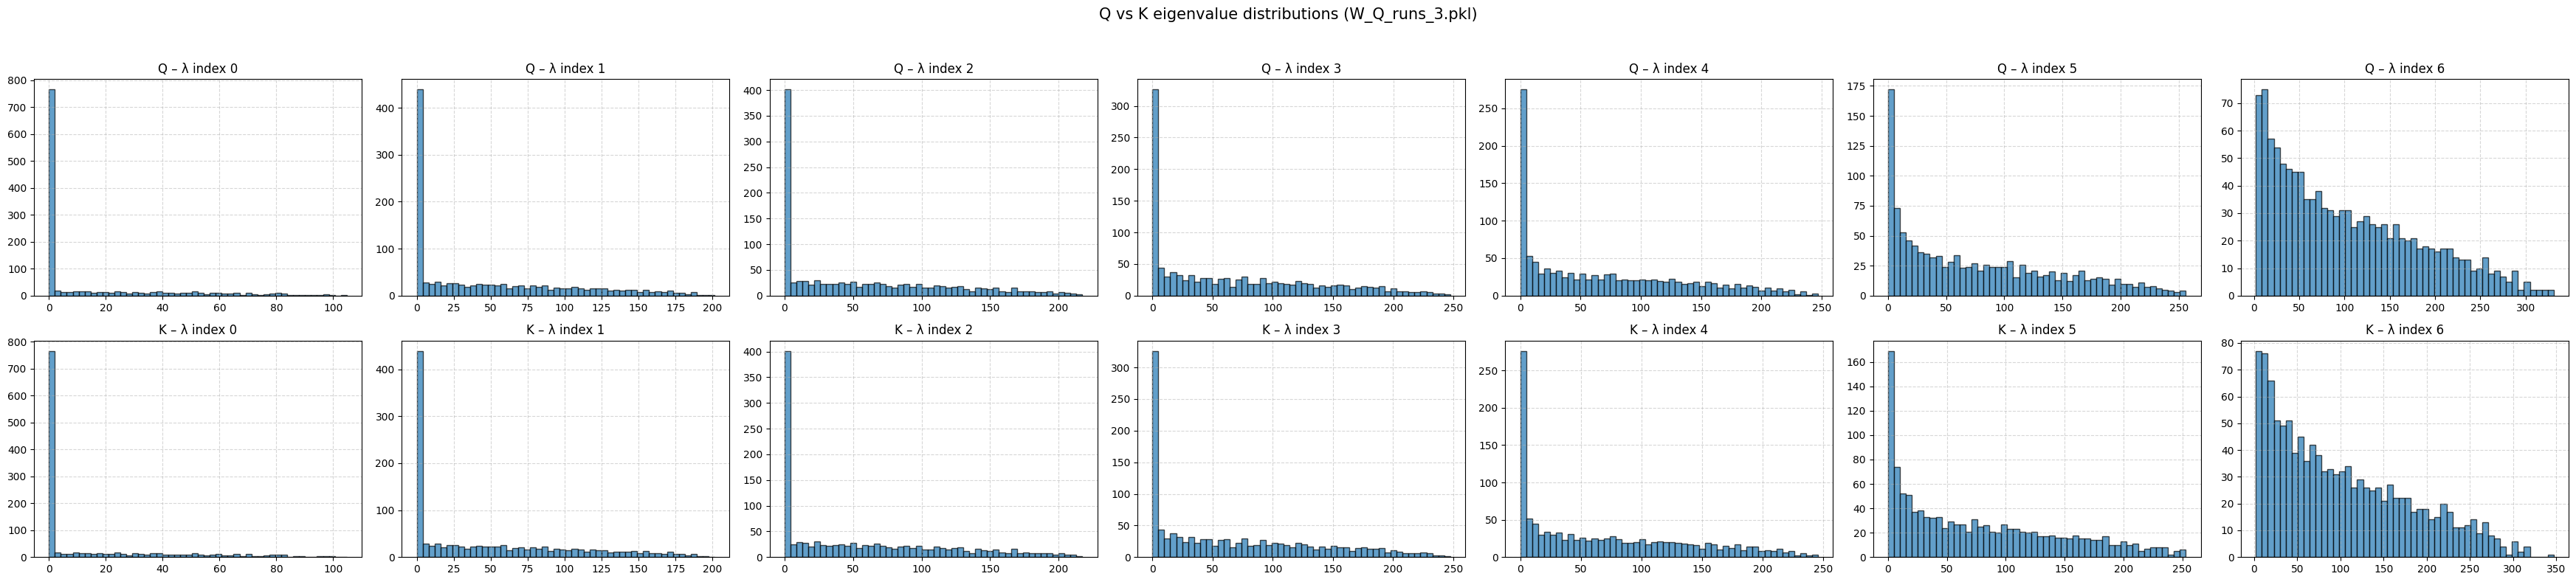


Comparing Q vs K for W_Q_runs_4.pkl


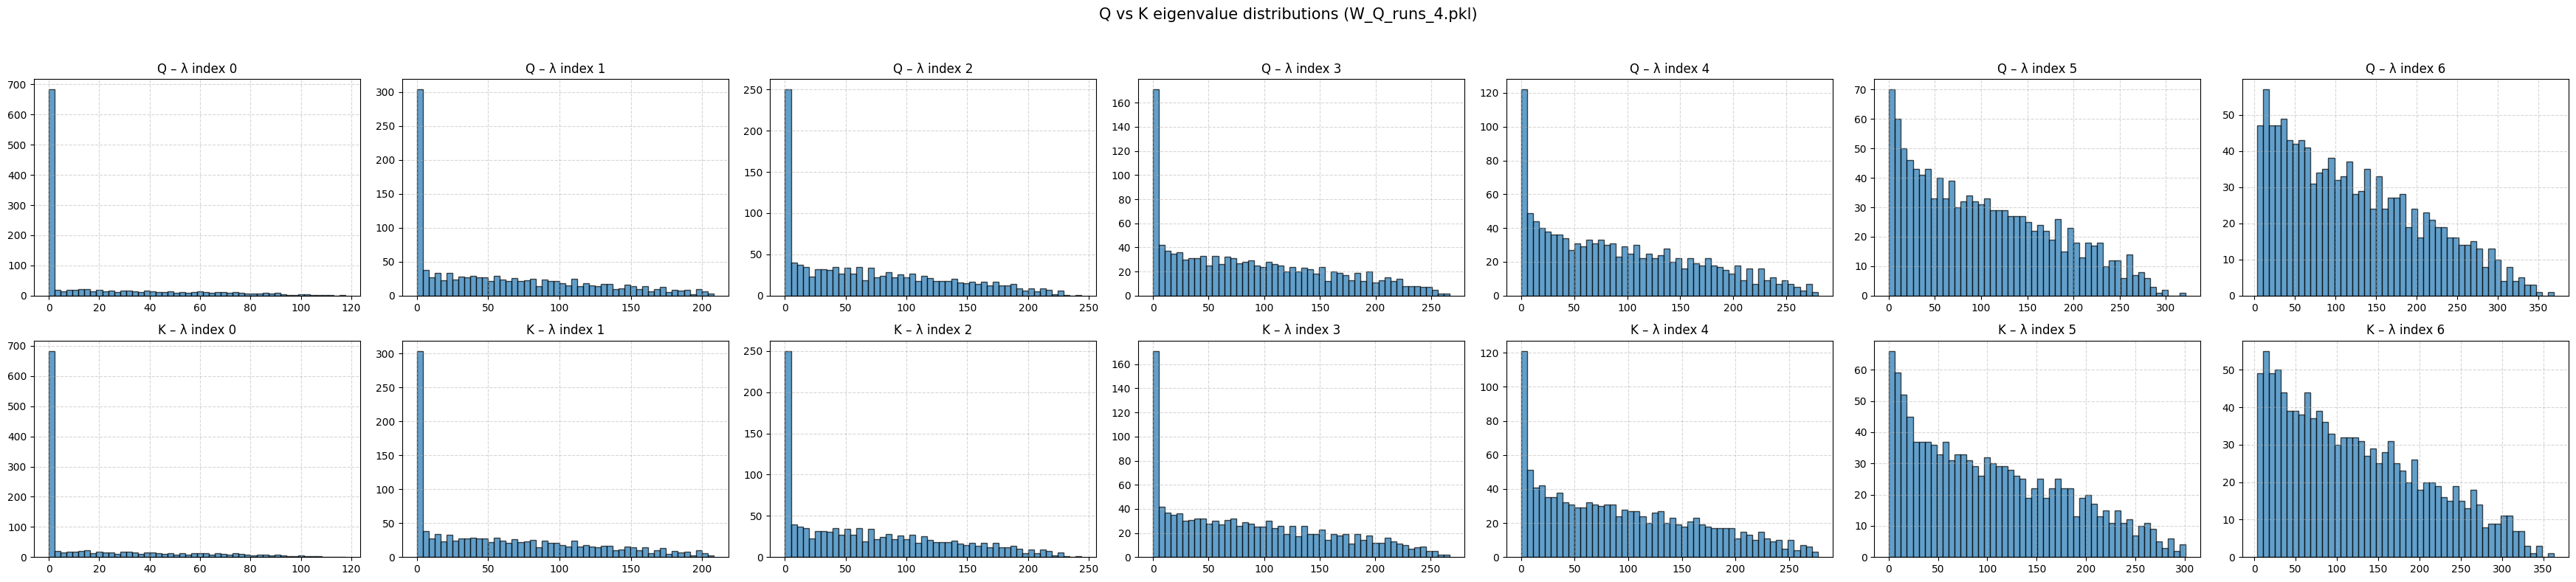


Comparing Q vs K for W_Q_runs_5.pkl


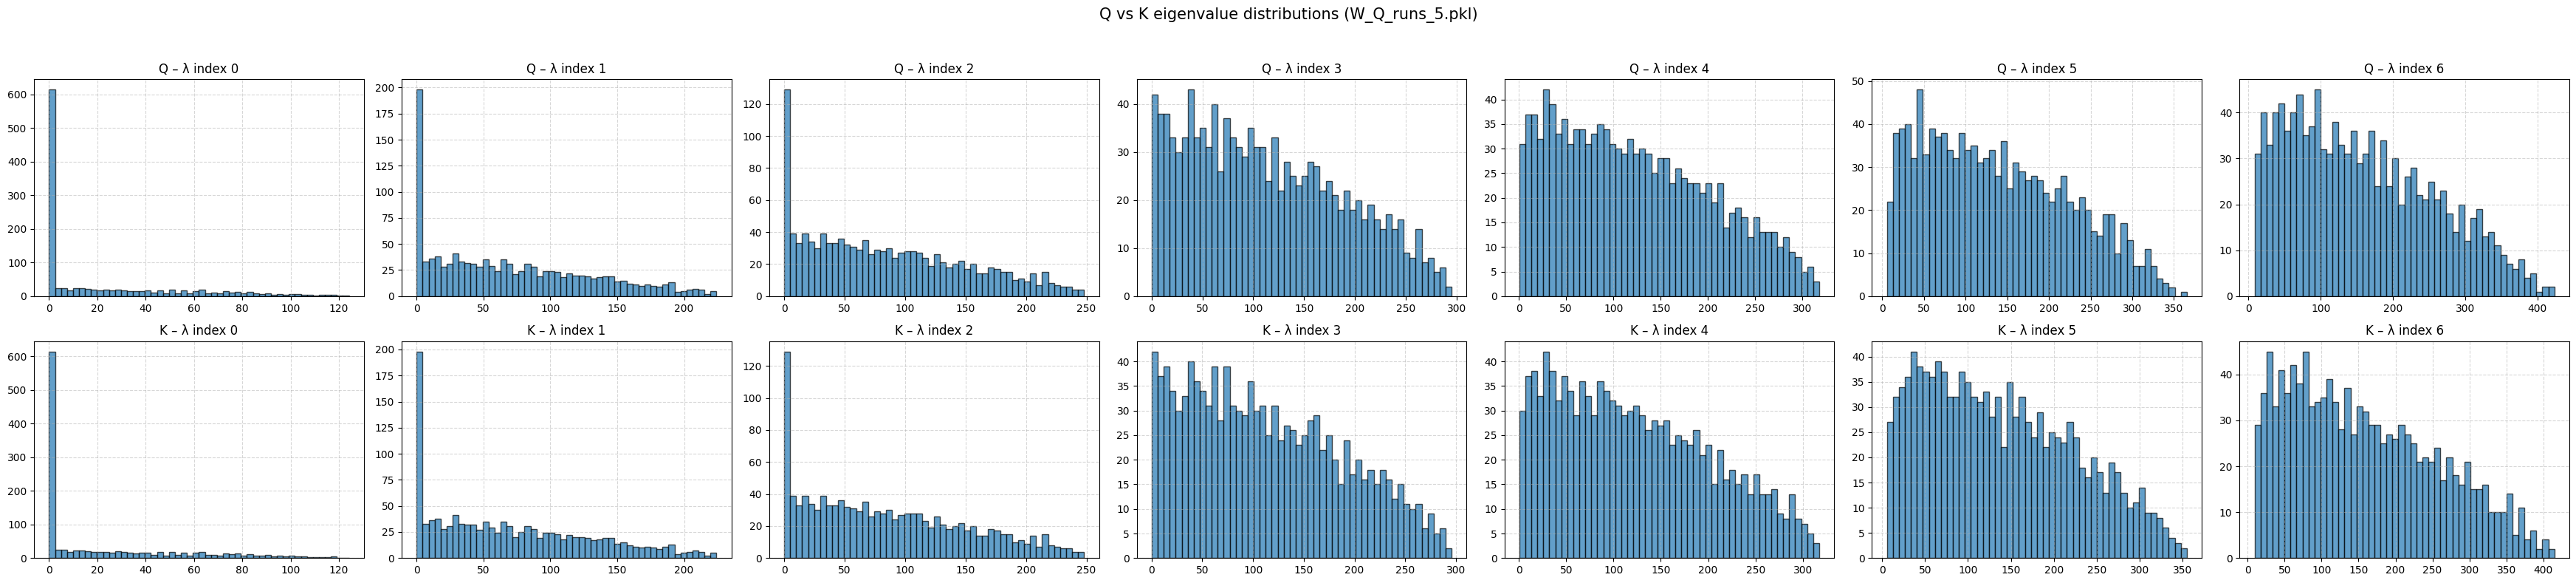


Comparing Q vs K for W_Q_runs_6.pkl


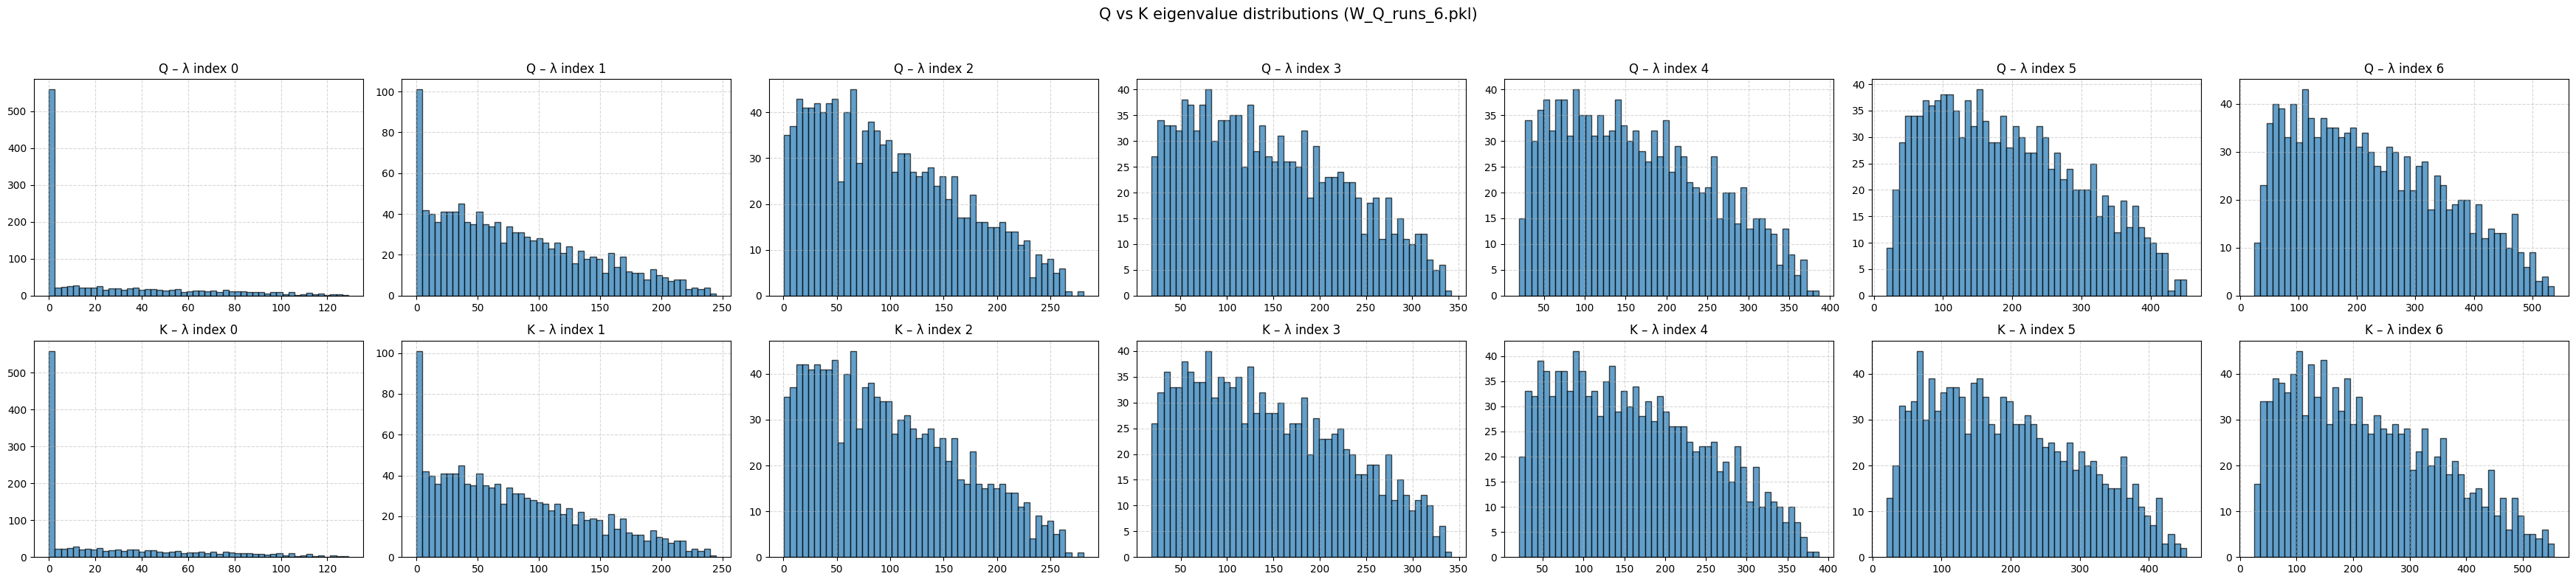


Comparing Q vs K for W_Q_runs_7.pkl


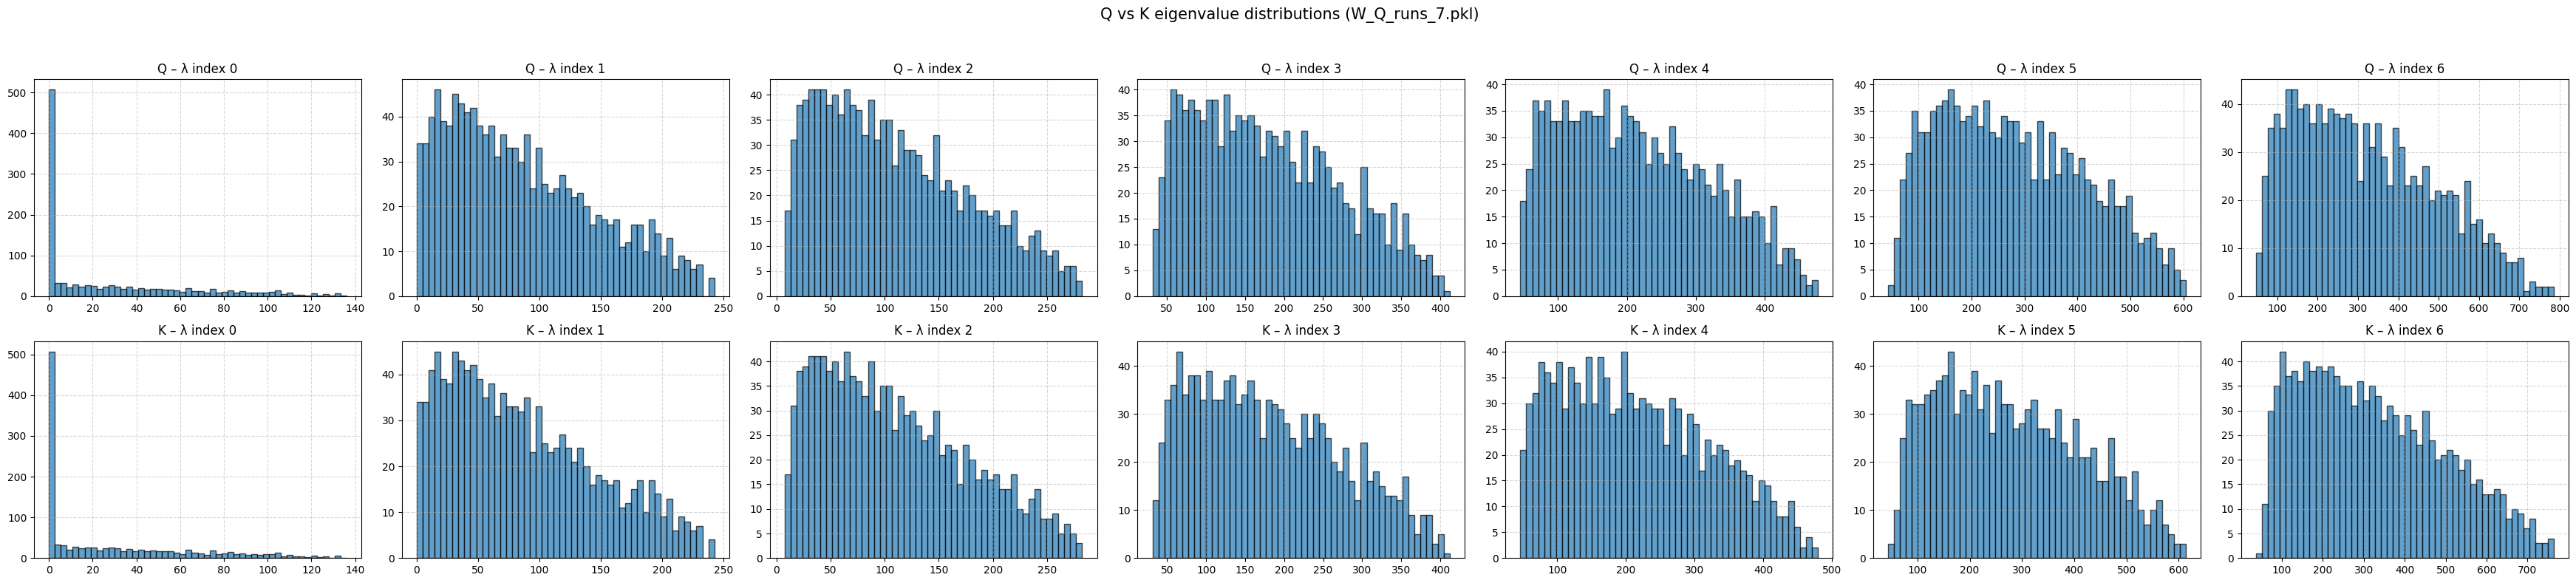


Comparing Q vs K for W_Q_runs_8.pkl


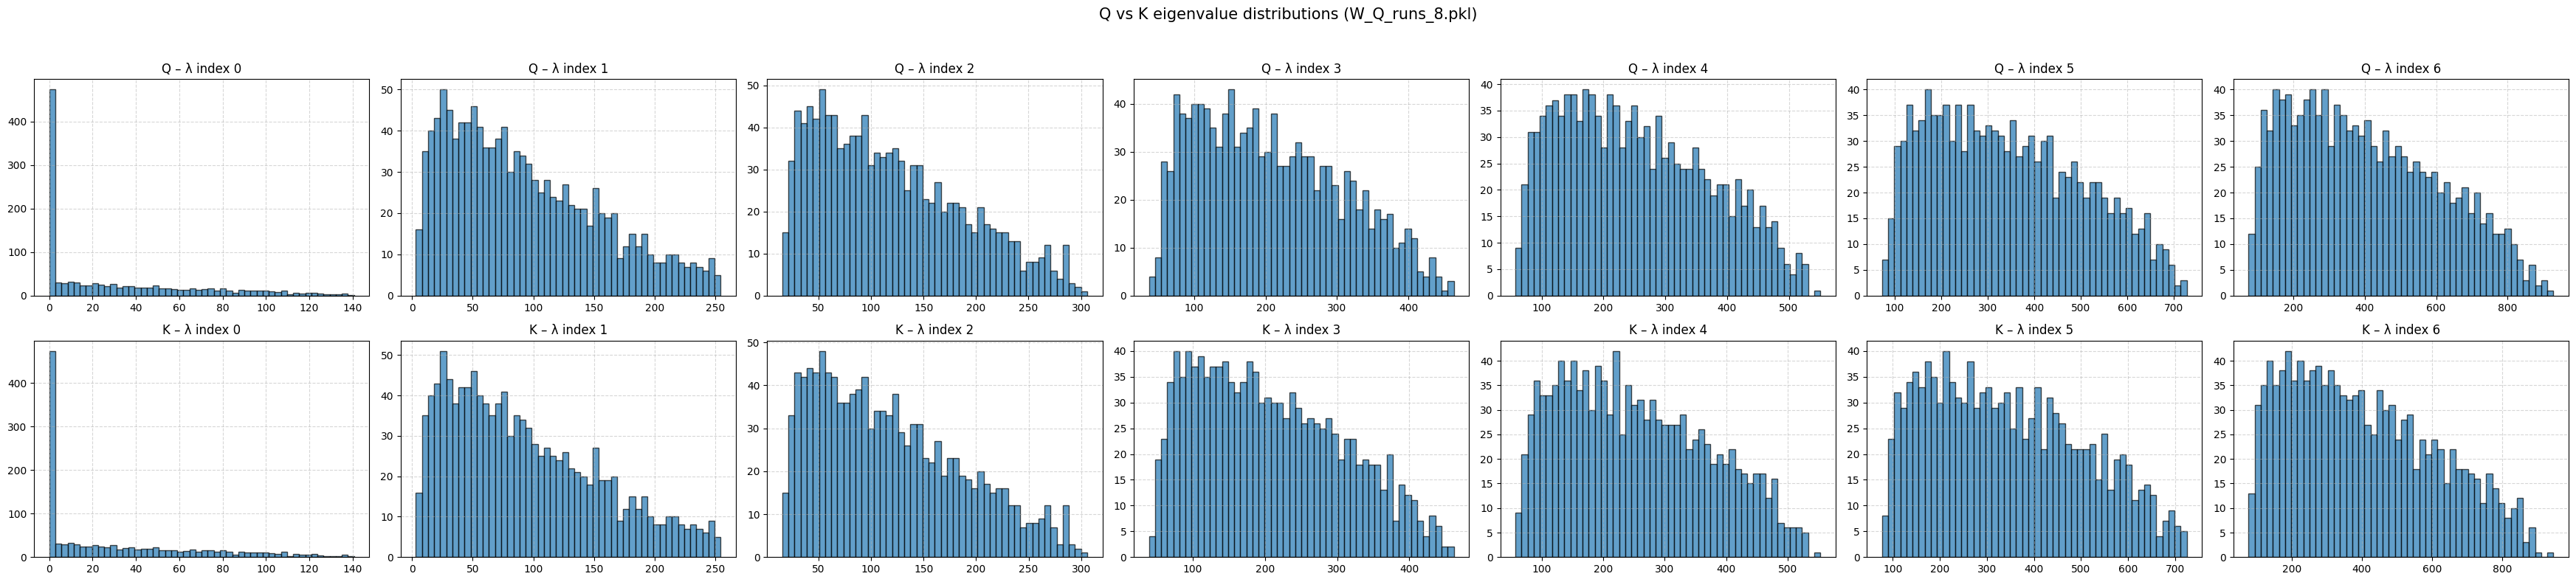


Comparing Q vs K for W_Q_runs_9.pkl


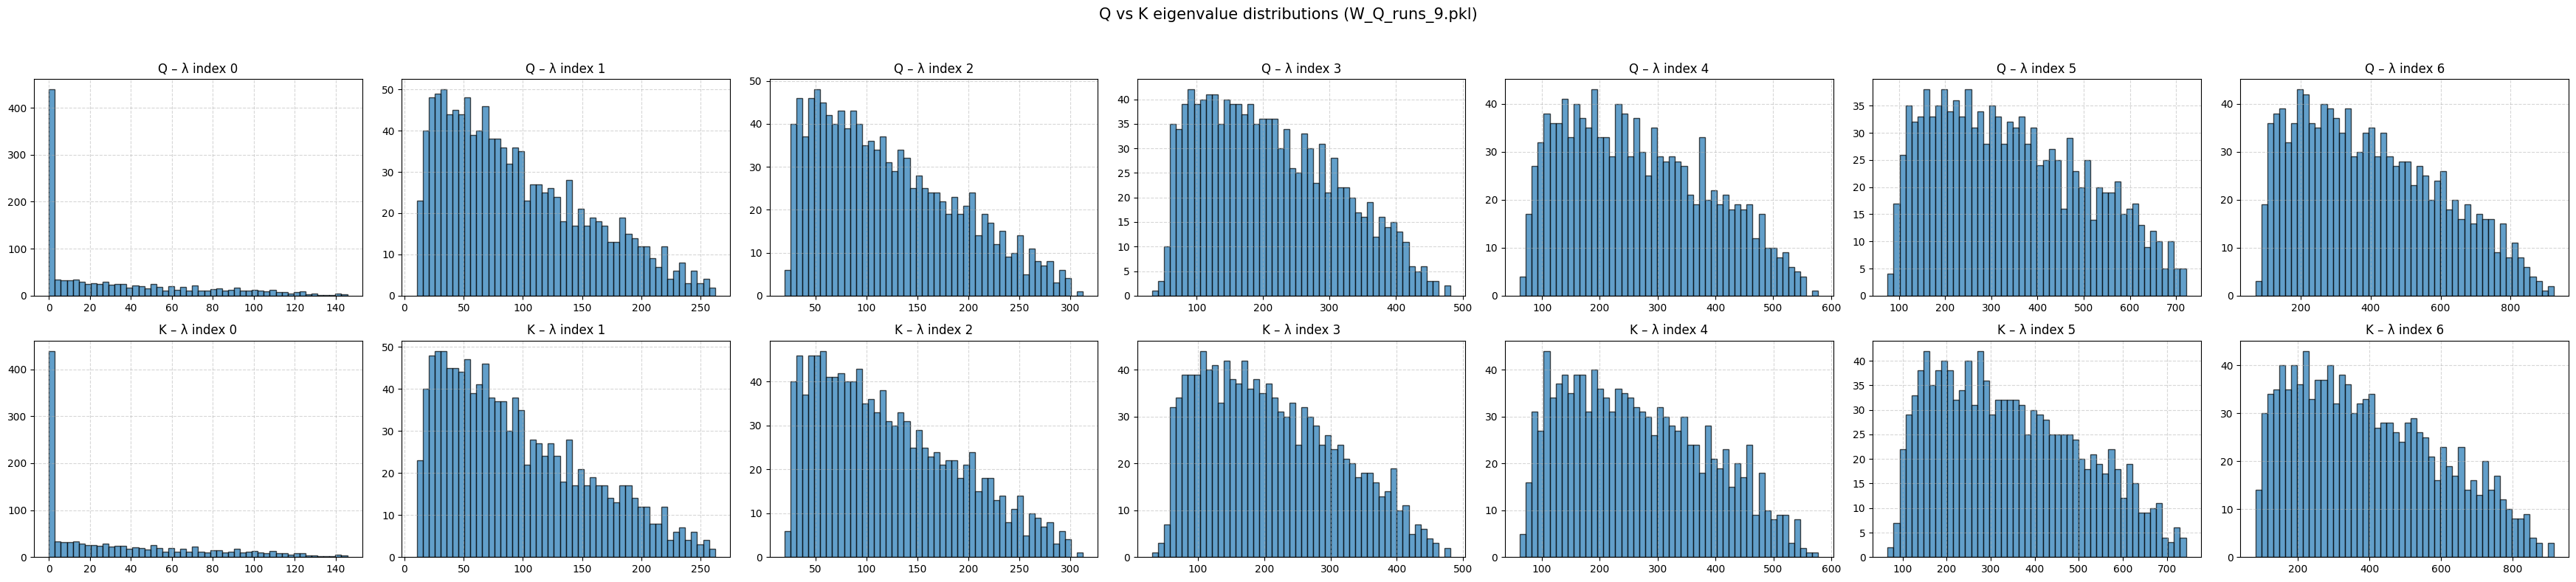

In [97]:
# --- Optional: side-by-side comparison if both Q and K exist for same index ---
for q_file, k_file in zip(pkl_Q_files, pkl_K_files):
    print(f"\nComparing Q vs K for {os.path.basename(q_file)}")

    with open(q_file, "rb") as fq, open(k_file, "rb") as fk:
        Q_runs_all = pickle.load(fq)
        K_runs_all = pickle.load(fk)

    num_lambda = min(len(Q_runs_all), len(K_runs_all))
    fig, axes = plt.subplots(2, num_lambda, figsize=(5*num_lambda, 8), squeeze=False)

    for i in range(num_lambda):
        # Q
        eigvals_Q = np.concatenate([np.linalg.eigvalsh(W @ W.T) for W in Q_runs_all[i]])
        axes[0, i].hist(eigvals_Q, bins=50, alpha=0.7, edgecolor='black')
        axes[0, i].set_title(f"Q – λ index {i}")
        axes[0, i].grid(True, linestyle="--", alpha=0.5)

        # K
        eigvals_K = np.concatenate([np.linalg.eigvalsh(W @ W.T) for W in K_runs_all[i]])
        axes[1, i].hist(eigvals_K, bins=50, alpha=0.7, edgecolor='black')
        axes[1, i].set_title(f"K – λ index {i}")
        axes[1, i].grid(True, linestyle="--", alpha=0.5)

    fig.suptitle(f"Q vs K eigenvalue distributions ({os.path.basename(q_file)})", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()